In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
from fnmatch import fnmatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial.distance import cdist
#import datacube
#from datacube.drivers.netcdf import write_dataset_to_netcdf
from scipy import stats
from scipy.stats import pearsonr
import seaborn as sns

In [2]:
#Function to select certain variables from files and concatenate
def process_daily_files(result_dir, files_to_open, variables_to_select, progress_bar=None):
    # Open the daily files as an xarray dataset
    ds = xr.open_mfdataset(str(result_dir / files_to_open), combine='nested')

    # Select specific variables
    ds = ds[variables_to_select]

    # Update progress bar
    if progress_bar:
        progress_bar.update(1)
    return ds

# Function to calculate Haversine distance from observed monitoring sites and irregularly gridded cells
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # approximate radius of Earth in km
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

def nrmse(observed, modelled):
    mse = np.mean((observed - modelled) ** 2)
    rmse_value = np.sqrt(mse)
    normalized_rmse = rmse_value / np.mean(observed)  # Normalize by mean
    return normalized_rmse

def calculate_cohens_d(modelled, observed):
    # Calculate the mean difference
    mean_diff = np.mean(modelled) - np.mean(observed)
    
    # Calculate the pooled standard deviation
    pooled_std = np.sqrt(((np.std(modelled, ddof=1) ** 2 + np.std(observed, ddof=1) ** 2) / 2))
    
    # Calculate Cohen's d
    cohens_d = abs(mean_diff / pooled_std)
    
    return cohens_d

def interpret_cohens_d(d):
    if d < 0.2:
        return "Small effect"
    elif 0.2 <= d < 0.8:
        return "Medium effect"
    else:
        return "Large effect"

In [3]:
# Define bounding box for CONUS (approximate)
lat_min, lat_max = 24.396308, 49.384358  # Southernmost and northernmost points
lon_min, lon_max = -125.0, -66.93457    # Westernmost and easternmost points

# Number of random points to generate
num_points = 2000  # Adjust for desired density

# Generate random latitudes and longitudes within the bounding box
lats = np.random.uniform(lat_min, lat_max, num_points)
lons = np.random.uniform(lon_min, lon_max, num_points)

# Create a Pandas DataFrame
random_points = pd.DataFrame({'latitude': lats, 'longitude': lons})
random_points.reset_index(inplace = True)
random_points['lon'] = 360-(random_points['longitude']*-1)
#random_points
#plot the points
#fig = px.scatter_geo(random_points, lat='latitude',  lon='longitude',   scope='usa')  # Set scope to USA for zoomed-in ma template='plotly')
#fig.show()


In [4]:
#Read in MUSICA data
result_dir = Path('/glade/derecho/scratch/demurray/archive/MUSICA_FCnudged30x8_20172018_082024/atm/hist')

files_to_open = 'MUSICA_FCnudged30x8_20172018_082024.cam.h0.*.nc'

variables_to_select = ['lat', 'lon', 'area','pom_a1SFWET', 'pom_a4SFWET', 'pom_c1SFWET', 'pom_c4SFWET', 
                       'soa1_a1SFWET', 'soa1_c1SFWET', 'soa1_a2SFWET', 'soa1_c2SFWET', 
                       'soa2_a1SFWET', 'soa2_c1SFWET', 'soa2_a2SFWET', 'soa2_c2SFWET', 
                       'soa3_a1SFWET', 'soa3_c1SFWET', 'soa3_a2SFWET',  'soa3_c2SFWET', 
                       'soa4_a1SFWET', 'soa4_c1SFWET', 'soa4_a2SFWET',  'soa4_c2SFWET', 
                       'soa5_a1SFWET', 'soa5_c1SFWET', 'soa5_a2SFWET',  'soa5_c2SFWET', 
                       'bc_a1SFWET', 'bc_a4SFWET', 'bc_c1SFWET', 'bc_c4SFWET', 'so4_a1SFWET', 
                       'so4_a2SFWET', 'so4_a3SFWET', 'so4_c1SFWET', 'so4_c2SFWET', 'so4_c3SFWET',
                       'WD_NH4', 'WD_HNO3', 'WD_NH3', 'PRECC', 'PRECL']

files_list = list(result_dir.glob(files_to_open))

# Initialize tqdm progress bar
progress = tqdm(total=len(files_list))

processed_data = []
for file in files_list:
    processed_data.append(process_daily_files(result_dir, file.relative_to(result_dir), variables_to_select, progress_bar=progress))

progress.close()

musica_daily = xr.concat(processed_data, dim='time').sortby('time')
musica_daily

  0%|          | 0/729 [00:00<?, ?it/s]/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'iris' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = 

<xarray.Dataset> Size: 23GB
Dimensions:       (time: 729, ncol: 174098)
Coordinates:
  * time          (time) datetime64[ns] 6kB 2017-01-01 2017-01-02 ... 2018-12-30
Dimensions without coordinates: ncol
Data variables: (12/42)
    lat           (time, ncol) float64 1GB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    lon           (time, ncol) float64 1GB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    area          (time, ncol) float64 1GB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_a1SFWET   (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_a4SFWET   (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_c1SFWET   (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    ...            ...
    so4_c3SFWET   (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH4        (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_HNO3       (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH3        (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PRECC         (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PRECL         (time, ncol) float32 508MB dask.array<chunksize=(1, 174098), meta=np.ndarray>
Attributes:
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              MUSICA_FCnudged30x8_20172018_082024
    logname:           demurray
    host:              derecho3
    initial_file:      /glade/derecho/scratch/demurray/inic/f.e22.FCnudged.ne...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [5]:
#Subset lat and lon for only over north america
musica_dim = musica_daily[['lat', 'lon']]
clipped_lat = musica_daily['lat'].clip(min=24, max=50)
clipped_lon = musica_daily['lon'].clip(min=235, max=294)

# Step 2: Update the dataset with clipped variables
musica_clipped = musica_dim.assign(lat=clipped_lat, lon=clipped_lon)
#musica_clipped

#Step 3. convert to a dataframe
mus_dim_df = musica_clipped.to_dataframe().reset_index()
mus_dim_df = mus_dim_df[['ncol', 'lat','lon']].drop_duplicates()
mus_dim_df = mus_dim_df.set_index('ncol')
mus_dim_df

,lat,lon
ncol,,
0,24.000000,235.000000
1,24.000000,235.000000
2,24.000000,235.375435
3,24.000000,235.764926
4,24.000000,235.000000
...,...,...
174093,47.263011,294.000000
174094,47.377896,294.000000
174095,47.216640,294.000000


In [6]:
# Calculate distances between all points in mus_df and random_points
distances = np.zeros((len(mus_dim_df), len(random_points)))

# Use tqdm to add a progress bar
for i, row in tqdm(mus_dim_df.iterrows(), total=len(mus_dim_df), desc='Calculating distances'):
    for j, row_random in random_points.iterrows():
        distances[i, j] = haversine(row['lat'], row['lon'], row_random['latitude'], row_random['lon'])

Calculating distances: 100%|██████████| 174098/174098 [3:55:36<00:00, 12.32it/s]  


In [7]:
random_points['pointId'] = random_points['index']
random_points

,index,latitude,longitude,lon,pointId
0,0,31.421041,-91.171988,268.828012,0
1,1,48.911714,-94.992113,265.007887,1
2,2,37.952696,-74.379821,285.620179,2
3,3,32.229206,-88.644394,271.355606,3
4,4,47.663290,-95.038593,264.961407,4
...,...,...,...,...,...
1995,1995,41.025156,-91.088216,268.911784,1995
1996,1996,36.900293,-81.933078,278.066922,1996
1997,1997,32.504692,-69.400066,290.599934,1997
1998,1998,44.644152,-115.567550,244.432450,1998


In [8]:
# Find the index of the closest point in mus_df for each point in random points
random_points['pointId'] = random_points['index']
closest_indices = np.argmin(distances, axis=0)

# Keep only the latitude and longitude pairs in mus_df that correspond to the closest points in ntn_loc
mus_df_matched = mus_dim_df.iloc[closest_indices]

# Assign the corresponding 'pointId' from random_points to mus_df_matched
mus_df_matched['index'] = random_points['pointId'].values
mus_df_matched = mus_df_matched.rename(columns = {'lat': 'lat_mod', 'lon' : 'lon_mod'})
mus_df_matched.reset_index(inplace = True) #checks -- there should be the same length of cells in mus_df_matched as ntn_loc
mus_df_matched['pointId'] = mus_df_matched['index']

mus_random = pd.merge(mus_df_matched, random_points, on = 'pointId', how = 'left') #looks good!
mus_random = mus_random[['ncol', 'lat_mod', 'lon_mod', 'pointId', 'latitude', 'longitude', 'lon']]
mus_random

/glade/derecho/scratch/demurray/tmp/ipykernel_12946/139908582.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mus_df_matched['index'] = random_points['pointId'].values


,ncol,lat_mod,lon_mod,pointId,latitude,longitude,lon
0,103730,31.505172,268.791112,0,31.421041,-91.171988,268.828012
1,156797,48.877583,265.042362,1,48.911714,-94.992113,265.007887
2,143849,37.959806,285.652704,2,37.952696,-74.379821,285.620179
3,104278,32.208982,271.321205,3,32.229206,-88.644394,271.355606
4,156750,47.585893,264.984519,4,47.663290,-95.038593,264.961407
...,...,...,...,...,...,...,...
1995,139995,41.070222,268.828480,1995,41.025156,-91.088216,268.911784
1996,124899,36.849583,278.070650,1996,36.900293,-81.933078,278.066922
1997,127970,32.487582,290.573143,1997,32.504692,-69.400066,290.599934
1998,151425,44.646453,244.542656,1998,44.644152,-115.567550,244.432450


In [9]:
#from here, make a dictionary of point ids that corresponds with model lat and lon and then 
#subset the xarray by this dictionary before perfroming any dataframe manipulation
# Step 1: Subset the xarray.Dataset using ncol
subset_ds = musica_daily.sel(ncol=mus_df_matched['ncol'].values)

# Step 2: Assign pointId to the subset xarray.Dataset
# Convert DataFrame to xarray.Dataset for easier assignment
pointId_da = xr.DataArray(mus_df_matched['pointId'].values, dims=['ncol'], coords={'ncol': mus_df_matched['ncol'].values})
subset_ds_RR = subset_ds.assign(pointId=pointId_da)
subset_ds_RR

<xarray.Dataset> Size: 262MB
Dimensions:       (time: 729, ncol: 2000)
Coordinates:
  * time          (time) datetime64[ns] 6kB 2017-01-01 2017-01-02 ... 2018-12-30
  * ncol          (ncol) int64 16kB 103730 156797 143849 ... 151425 116104
Data variables: (12/43)
    lat           (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    lon           (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    area          (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pom_a1SFWET   (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pom_a4SFWET   (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pom_c1SFWET   (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    ...            ...
    WD_NH4        (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_HNO3       (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_NH3        (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PRECC         (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PRECL         (time, ncol) float32 6MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pointId       (ncol) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
Attributes:
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              MUSICA_FCnudged30x8_20172018_082024
    logname:           demurray
    host:              derecho3
    initial_file:      /glade/derecho/scratch/demurray/inic/f.e22.FCnudged.ne...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [10]:
#Clean the RR subset dataframe

# Calculate SO4_wet_sum
subset_ds_RR['SO4_wet_sum'] = (subset_ds_RR['so4_a1SFWET'] + subset_ds_RR['so4_a2SFWET'] + subset_ds_RR['so4_a3SFWET'] 
                                + subset_ds_RR['so4_c1SFWET'] + subset_ds_RR['so4_c2SFWET'] + subset_ds_RR['so4_c3SFWET']) * -1

# Calculate NO3_wet and correct for molar mass
subset_ds_RR['NO3_wet'] = subset_ds_RR['WD_HNO3'] * -1 * 0.984006

# Calculate NH4_wet and correct for data sign
subset_ds_RR['WD_NH4_corr'] = xr.where(subset_ds_RR['WD_NH4'] > 0, 0, subset_ds_RR['WD_NH4'])
subset_ds_RR['WD_NH3_corr'] = xr.where(subset_ds_RR['WD_NH3'] > 0, 0, subset_ds_RR['WD_NH3'])

#Calculate total precipitation
subset_ds_RR['PRECC_mm'] = subset_ds_RR['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
subset_ds_RR['PRECL_mm'] = subset_ds_RR['PRECL']* (86400*1000)
subset_ds_RR['PREC_tot_mm'] = subset_ds_RR['PRECC_mm']  + subset_ds_RR['PRECL_mm']

#Calculate BC wet sum
subset_ds_RR['BC_wet_sum'] = (subset_ds_RR['bc_a1SFWET'] + subset_ds_RR['bc_a4SFWET'] + subset_ds_RR['bc_c1SFWET'] 
                                + subset_ds_RR['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
subset_ds_RR['SOA_POM_wet_sum'] = (subset_ds_RR['soa1_a1SFWET'] + subset_ds_RR['soa1_a2SFWET'] + subset_ds_RR['soa1_c1SFWET'] 
                             + subset_ds_RR['soa1_c2SFWET'] + subset_ds_RR['soa2_a1SFWET'] + subset_ds_RR['soa2_a2SFWET'] 
                             + subset_ds_RR['soa2_c1SFWET'] +  subset_ds_RR['soa2_c2SFWET'] + subset_ds_RR['soa3_a1SFWET'] 
                             + subset_ds_RR['soa3_a2SFWET'] + subset_ds_RR['soa3_c1SFWET'] + subset_ds_RR['soa3_c2SFWET'] 
                             + subset_ds_RR['soa4_a1SFWET'] + subset_ds_RR['soa4_a2SFWET'] + subset_ds_RR['soa4_c1SFWET'] 
                             + subset_ds_RR['soa4_c2SFWET'] + subset_ds_RR['soa5_a1SFWET'] + subset_ds_RR['soa5_a2SFWET'] 
                             + subset_ds_RR['soa5_c1SFWET'] + subset_ds_RR['soa5_c2SFWET'] + subset_ds_RR['pom_a1SFWET']
                             + subset_ds_RR['pom_a4SFWET'] + subset_ds_RR['pom_c1SFWET'] + subset_ds_RR['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
subset_ds_RR['DOC_wet_sum'] = subset_ds_RR['BC_wet_sum']  + subset_ds_RR['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
subset_ds_RR = subset_ds_RR.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum','WD_NH3_corr', 'WD_NH4_corr', 'NO3_wet', 'DOC_wet_sum'] else x)
subset_ds_RR = subset_ds_RR[['lat', 'lon', 'pointId', 'DOC_wet_sum', 'PRECL_mm','PRECC_mm', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_corr','WD_NH3_corr' ,'NO3_wet']]
subset_ds_RR

<xarray.Dataset> Size: 117MB
Dimensions:      (time: 729, ncol: 2000)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2017-01-01 2017-01-02 ... 2018-12-30
  * ncol         (ncol) int64 16kB 103730 156797 143849 ... 127970 151425 116104
Data variables:
    lat          (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    lon          (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pointId      (ncol) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
    DOC_wet_sum  (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PRECL_mm     (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PRECC_mm     (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PREC_tot_mm  (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    SO4_wet_sum  (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_NH4_corr  (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_NH3_corr  (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>
    NO3_wet      (time, ncol) float64 12MB dask.array<chunksize=(1, 2000), meta=np.ndarray>

In [11]:
#Next read in the global model files, loop through to find nearest to random_points, and then merge with subset_df on pointId
#Read in SO4, NO3, NH4 wet dep timeseries files
daily_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
daily_so4_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_HNO3.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH4.nc', 
                            'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH3.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a3SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c3SFWET.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [daily_result_dir / file_name for file_name in daily_so4_files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily_inorg = xr.open_mfdataset(file_paths, combine='nested')

#Read in BC wet dep timeseries files
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
bc_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.a2x_BCPHIWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECC.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECL.nc']

file_paths = [result_dir / file_name for file_name in bc_files_to_open]
nc_daily_bc = xr.open_mfdataset(file_paths, combine='nested')

#read in POM files
daily_pom_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.pom_*SFWET.nc'
nc_daily_pom = xr.open_mfdataset(str(result_dir/daily_pom_to_open),combine='nested')

#read in SOA
soa_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_SOAvars/')
daily_soa_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.*SFWET.nc'
nc_daily_soa = xr.open_mfdataset(str(soa_result_dir/daily_soa_to_open),combine='nested')

##merge SOA and POM files together
nc_daily = xr.merge([nc_daily_soa, nc_daily_pom, nc_daily_bc, nc_daily_inorg])
nc_daily

#subset for only 2017 and 2018
start = dt.datetime.strptime('2017-01-01', '%Y-%m-%d')
end = dt.datetime.strptime('2018-12-30', '%Y-%m-%d')
nc_daily = nc_daily.sel(time=slice(start, end))

#Clean data
# Calculate SO4_wet_sum
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1

# Calculate NO3_wet and correct for molar mass
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006

# Calculate NH4_wet and correct for data sign
nc_daily['WD_NH4_corr'] = xr.where(nc_daily['WD_NH4'] > 0, 0, nc_daily['WD_NH4'])
nc_daily['WD_NH3_corr'] = xr.where(nc_daily['WD_NH3'] > 0, 0, nc_daily['WD_NH3'])

#Calculate total precipitation
nc_daily['PRECC_mm'] = nc_daily['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_daily['PRECL_mm'] = nc_daily['PRECL']* (86400*1000)
nc_daily['PREC_tot_mm'] = nc_daily['PRECC_mm']  + nc_daily['PRECL_mm']

#Calculate BC wet sum
nc_daily['BC_wet_sum'] = (nc_daily['bc_a1SFWET'] + nc_daily['bc_a4SFWET'] + nc_daily['bc_c1SFWET'] 
                                + nc_daily['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
nc_daily['SOA_POM_wet_sum'] = (nc_daily['soa1_a1SFWET'] + nc_daily['soa1_a2SFWET'] + nc_daily['soa1_c1SFWET'] 
                             + nc_daily['soa1_c2SFWET'] + nc_daily['soa2_a1SFWET'] + nc_daily['soa2_a2SFWET'] 
                             + nc_daily['soa2_c1SFWET'] +  nc_daily['soa2_c2SFWET'] + nc_daily['soa3_a1SFWET'] 
                             + nc_daily['soa3_a2SFWET'] + nc_daily['soa3_c1SFWET'] + nc_daily['soa3_c2SFWET'] 
                             + nc_daily['soa4_a1SFWET'] + nc_daily['soa4_a2SFWET'] + nc_daily['soa4_c1SFWET'] 
                             + nc_daily['soa4_c2SFWET'] + nc_daily['soa5_a1SFWET'] + nc_daily['soa5_a2SFWET'] 
                             + nc_daily['soa5_c1SFWET'] + nc_daily['soa5_c2SFWET'] + nc_daily['pom_a1SFWET']
                             + nc_daily['pom_a4SFWET'] + nc_daily['pom_c1SFWET'] + nc_daily['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
nc_daily['DOC_wet_sum'] = nc_daily['BC_wet_sum']  + nc_daily['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_corr', 'WD_NH3_corr','NO3_wet', 'DOC_wet_sum'] else x)
nc_daily = nc_daily[['lat', 'lon', 'DOC_wet_sum', 'PRECC_mm', 'PRECL_mm', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_corr', 'WD_NH3_corr','NO3_wet']]

#Select cells that correspond to random points: apply the find nearest function

# Only select the cells in .nc that correspond to an random point lat/lon
subset_list = []
progress_bar = tqdm(total=len(random_points))
for index, row in random_points.iterrows():
    lat = row['latitude']
    lon = row['lon']   # longitude is positive and based on 360 degrees.
    lat_idx = find_index(nc_daily['lat'].values, lat)   # right now we are doing a 'find nearest' calculation, should probably interpolate across grid cell and have exact coordinates represented?
    lon_idx = find_index(nc_daily['lon'].values, lon)
    subset = nc_daily.isel(lat=lat_idx, lon=lon_idx)
    subset['pointId'] = row['pointId']  # Add 'siteId' as a new coordinate/index
    subset = subset.assign_coords(pointId=row['pointId'])
    subset_list.append(subset)
    progress_bar.update(1)
progress_bar.close()

# Concatenate the list of subsets into a new xarray dataset
nc_daily_glob_subset = xr.concat(subset_list, dim='pointId')
nc_daily_glob_subset

100%|██████████| 2000/2000 [00:11<00:00, 179.18it/s]


<xarray.Dataset> Size: 93MB
Dimensions:      (pointId: 2000, time: 729)
Coordinates:
    lat          (pointId) float64 16kB 31.57 48.53 38.17 ... 32.51 44.76 32.51
    lon          (pointId) float64 16kB 268.8 265.0 285.0 ... 290.0 245.0 256.2
  * time         (time) datetime64[ns] 6kB 2017-01-01 2017-01-02 ... 2018-12-30
  * pointId      (pointId) float64 16kB 0.0 1.0 2.0 ... 1.998e+03 1.999e+03
Data variables:
    DOC_wet_sum  (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    PRECC_mm     (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    PRECL_mm     (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    PREC_tot_mm  (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    SO4_wet_sum  (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    WD_NH4_corr  (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    WD_NH3_corr  (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>
    NO3_wet      (pointId, time) float64 12MB dask.array<chunksize=(1, 729), meta=np.ndarray>

In [12]:
#Calculate the average daily value for each variable and then convert to dataframe for global dataset and regionally refined dataset
ds_mean_glob = nc_daily_glob_subset.mean(dim='time')
df_mean_glob = ds_mean_glob.to_dataframe().reset_index()
df_mean_glob['WD_NH4_corr'] = df_mean_glob['WD_NH4_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code
df_mean_glob['WD_NH3_corr'] = df_mean_glob['WD_NH3_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code

df_mean_glob = df_mean_glob.replace(-0.0, 0)

#RR
ds_mean_RR = subset_ds_RR.mean(dim='time')
df_mean_RR = ds_mean_RR.to_dataframe().reset_index()
df_mean_RR['WD_NH4_corr'] = df_mean_RR['WD_NH4_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code
df_mean_RR['WD_NH3_corr'] = df_mean_RR['WD_NH3_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code

df_mean_RR = df_mean_RR.replace(-0.0, 0)

In [15]:
#Formatting the RR output
df_mean_RR_long = pd.melt(df_mean_RR, id_vars = ['pointId', 'lat', 'lon', 'ncol'])
df_mean_RR_long = df_mean_RR_long[['pointId', 'lat', 'lon', 'variable', 'value']]
df_mean_RR_long = df_mean_RR_long.rename(columns = {'lat' : 'lat_RR', 'lon' : 'lon_RR', 'value' : 'Value_RR'})
#df_mean_RR_long 

#Formatting the global output
df_mean_glob_long = pd.melt(df_mean_glob, id_vars = ['pointId', 'lat', 'lon'])
df_mean_glob_long = df_mean_glob_long[['pointId', 'lat', 'lon', 'variable', 'value']]
df_mean_glob_long = df_mean_glob_long.rename(columns = {'lat' : 'lat_glob', 'lon' : 'lon_glob', 'value' : 'Value_Global'})
df_mean_glob_long 

#Merge the two datasets together
df_mean_glob_RR = pd.merge(df_mean_RR_long, df_mean_glob_long, on = ['pointId', 'variable'])
df_mean_glob_RR.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/RR Global CONUS comparison.csv')
df_mean_glob_RR

,pointId,lat_RR,lon_RR,variable,Value_RR,lat_glob,lon_glob,Value_Global
0,0,31.505172,268.791112,DOC_wet_sum,1.230656,31.570681,268.75,1.365939
1,1,48.877583,265.042362,DOC_wet_sum,0.565669,48.534031,265.00,0.793366
2,2,37.959806,285.652704,DOC_wet_sum,0.635986,38.167539,285.00,0.885689
3,3,32.208982,271.321205,DOC_wet_sum,1.520791,32.513089,271.25,1.743877
4,4,47.585893,264.984519,DOC_wet_sum,0.581953,47.591623,265.00,0.787067
...,...,...,...,...,...,...,...,...
15995,1995,41.070222,268.828480,NO3_wet,2.956824,40.994764,268.75,2.772151
15996,1996,36.849583,278.070650,NO3_wet,3.392276,37.225131,277.50,2.854737
15997,1997,32.487582,290.573143,NO3_wet,1.321641,32.513089,290.00,1.208936
15998,1998,44.646453,244.542656,NO3_wet,1.198586,44.764398,245.00,1.101946


In [2]:
#Read in data: 
df_mean_glob_RR = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/RR Global CONUS comparison.csv')


In [3]:
#Bin data by longtiudes

# Define the bin edges (in 0–360° format)
bin_edges = [235, 240, 251, 257, 272, 285, 293]

# Define corresponding region labels (same length as bin_edges - 1)
region_labels = [
    "West Coast",
    "Southwest",
    "Mountain West",
    "Midwest",
    "Southeast",
    "East Coast"
]

# Apply binning to the longitude column
df_mean_glob_RR["region"] = pd.cut(
    df_mean_glob_RR["lon_glob"],
    bins=bin_edges,
    labels=region_labels,
    include_lowest=True,
    right=False  # Make bins left-inclusive, right-exclusive: [)
)
df_mean_glob_RR

,Unnamed: 0,pointId,lat_RR,lon_RR,variable,Value_RR,lat_glob,lon_glob,Value_Global,region
0,0,0,31.505172,268.791112,DOC_wet_sum,1.230656,31.570681,268.75,1.365939,Midwest
1,1,1,48.877583,265.042362,DOC_wet_sum,0.565669,48.534031,265.00,0.793366,Midwest
2,2,2,37.959806,285.652704,DOC_wet_sum,0.635986,38.167539,285.00,0.885689,East Coast
3,3,3,32.208982,271.321205,DOC_wet_sum,1.520791,32.513089,271.25,1.743877,Midwest
4,4,4,47.585893,264.984519,DOC_wet_sum,0.581953,47.591623,265.00,0.787067,Midwest
...,...,...,...,...,...,...,...,...,...,...
15995,15995,1995,41.070222,268.828480,NO3_wet,2.956824,40.994764,268.75,2.772151,Midwest
15996,15996,1996,36.849583,278.070650,NO3_wet,3.392276,37.225131,277.50,2.854737,Southeast
15997,15997,1997,32.487582,290.573143,NO3_wet,1.321641,32.513089,290.00,1.208936,East Coast
15998,15998,1998,44.646453,244.542656,NO3_wet,1.198586,44.764398,245.00,1.101946,Southwest


NRMSE = 0.29
R = 0.93


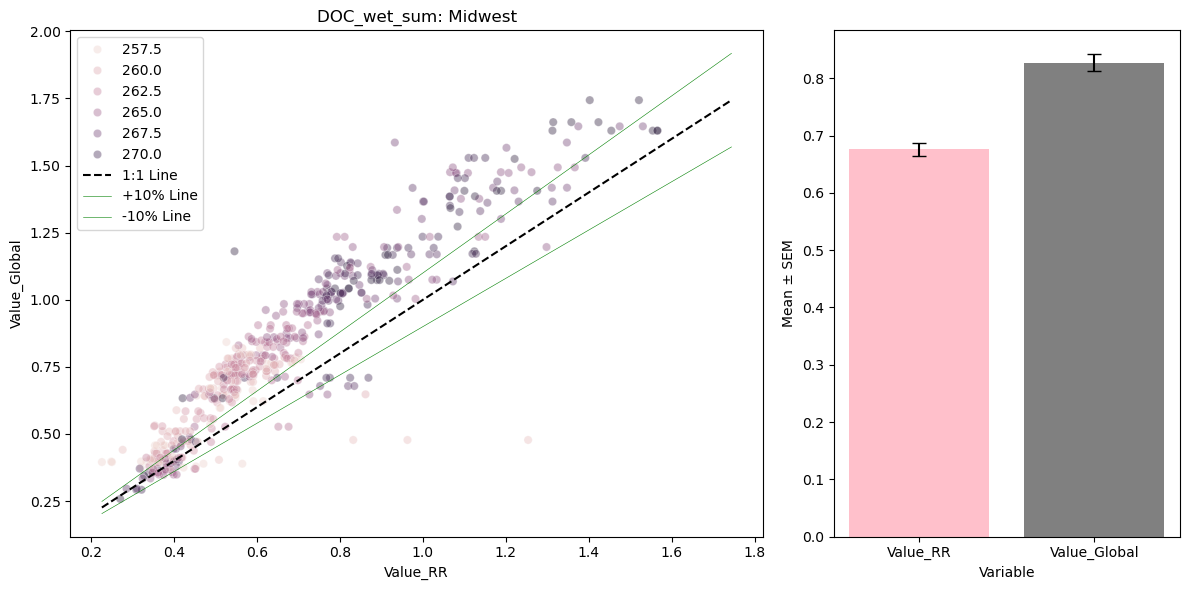

NRMSE = 0.25
R = 0.98


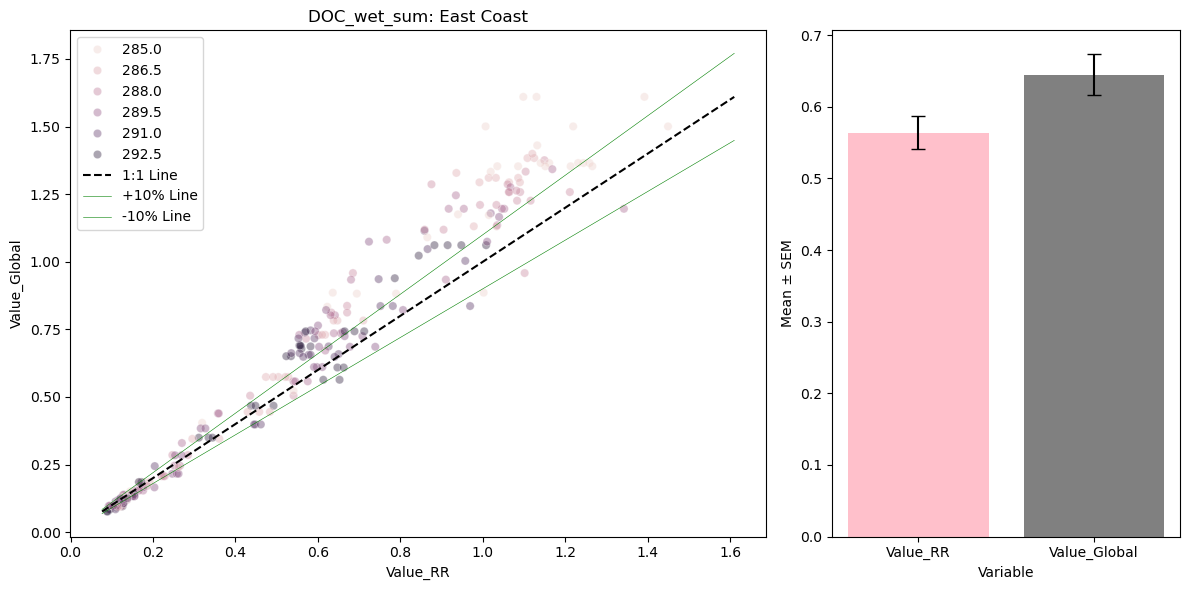

NRMSE = 0.27
R = 0.96


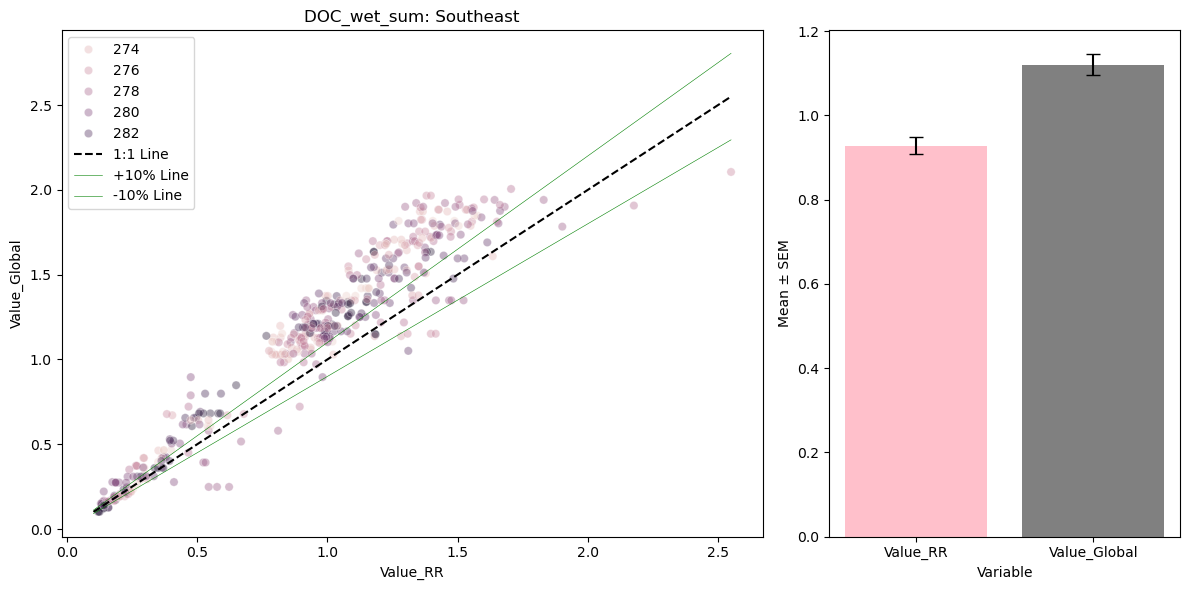

NRMSE = 0.36
R = 0.6


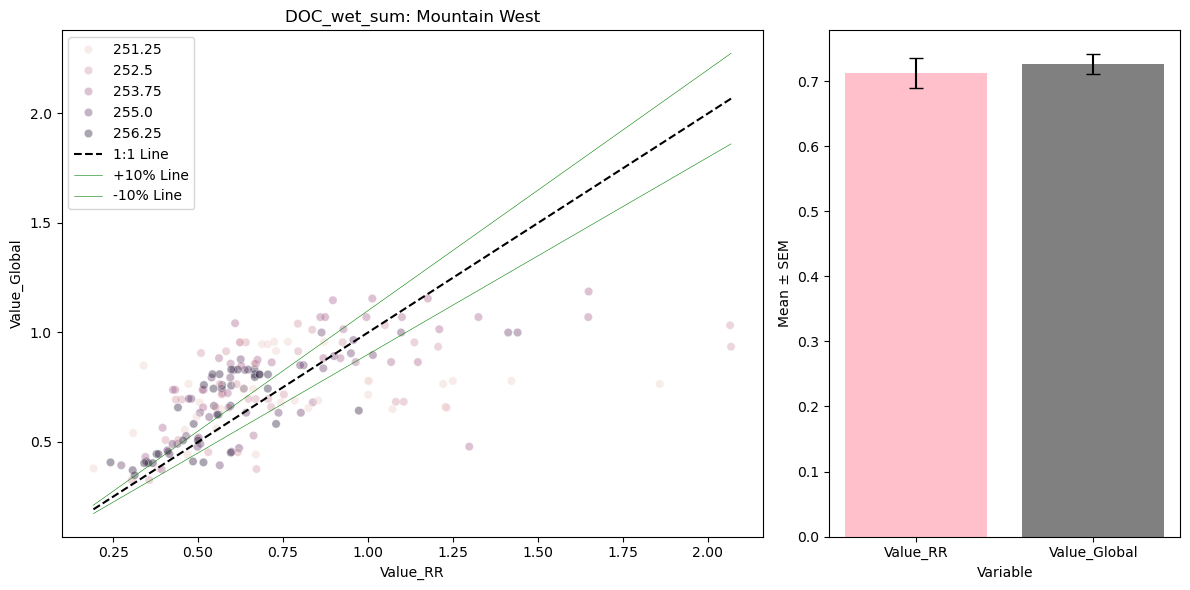

NRMSE = 0.4
R = 0.89


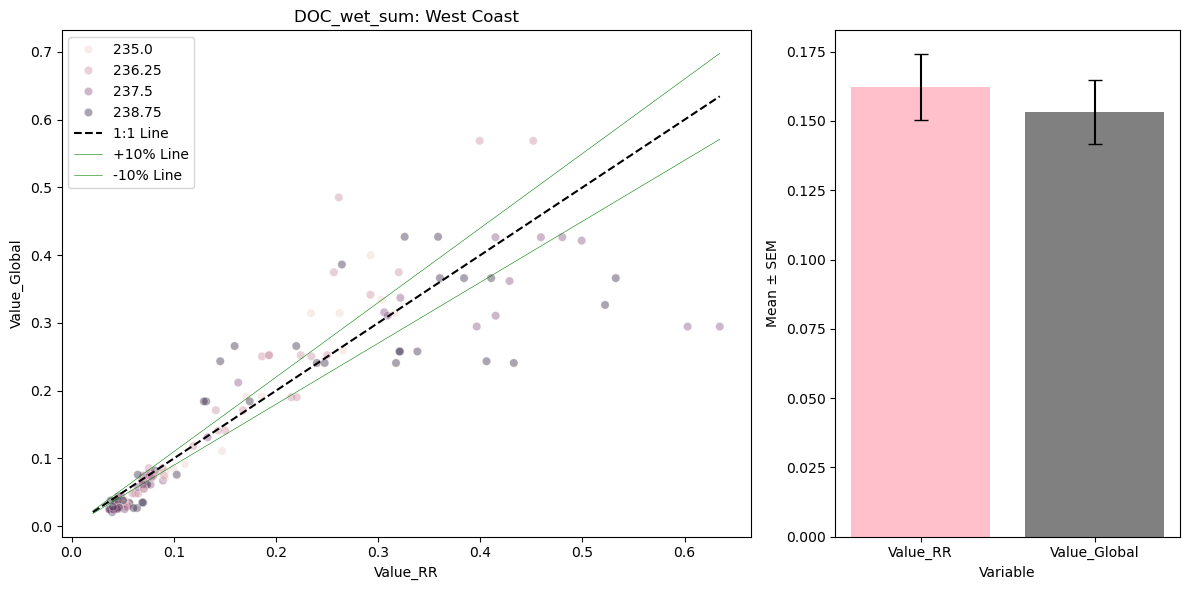

NRMSE = 0.4
R = 0.9


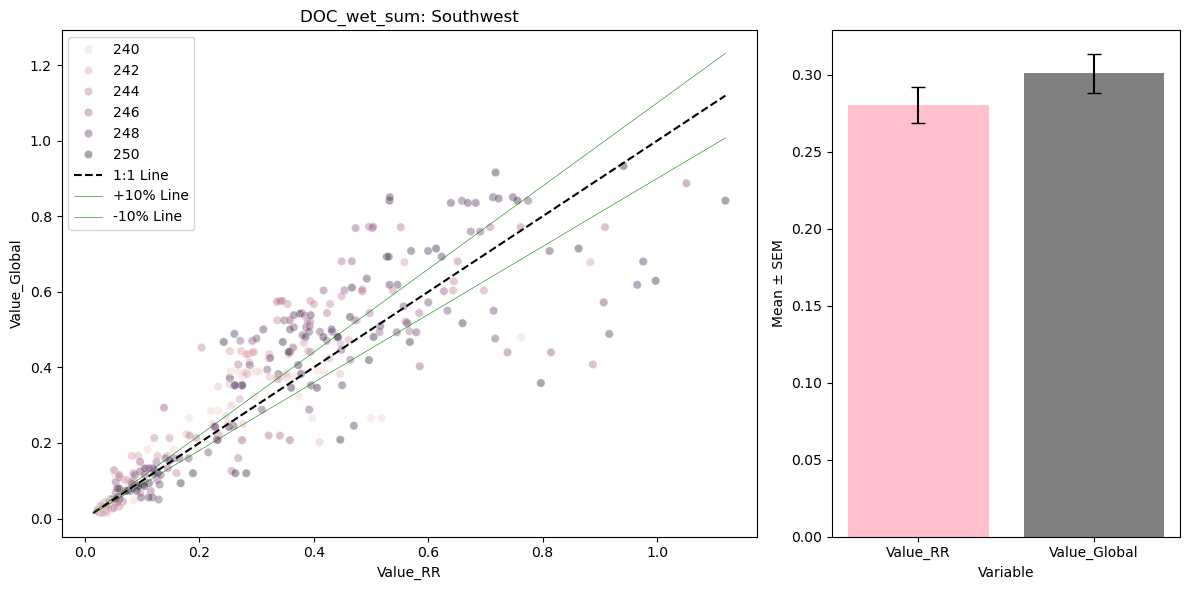

NRMSE = 0.5
R = 0.62


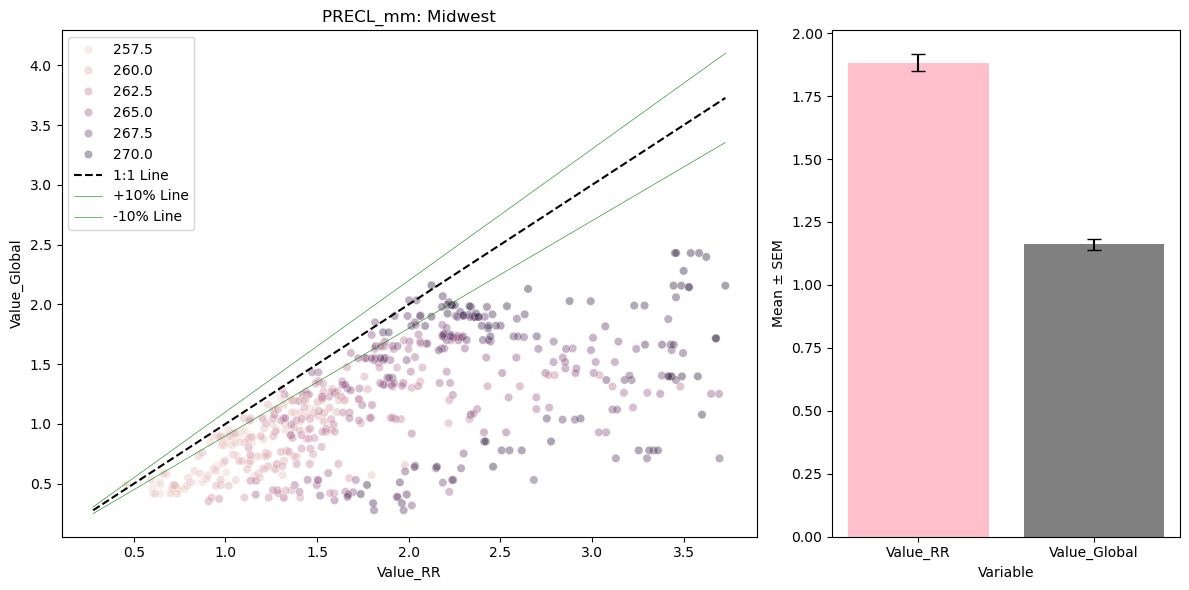

NRMSE = 0.42
R = 0.73


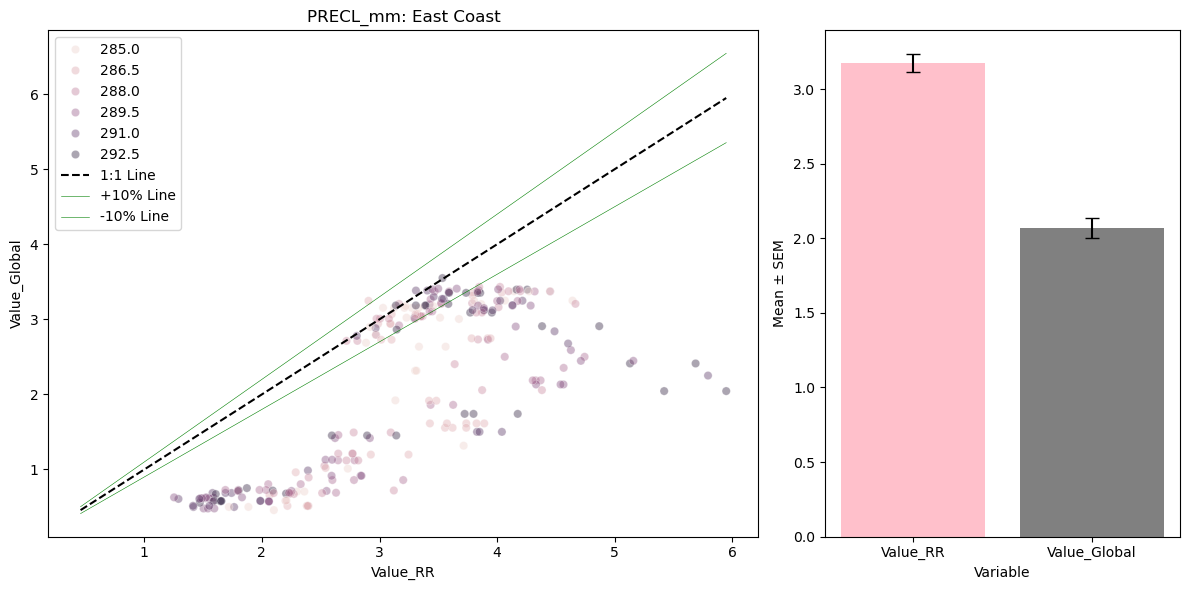

NRMSE = 0.42
R = 0.62


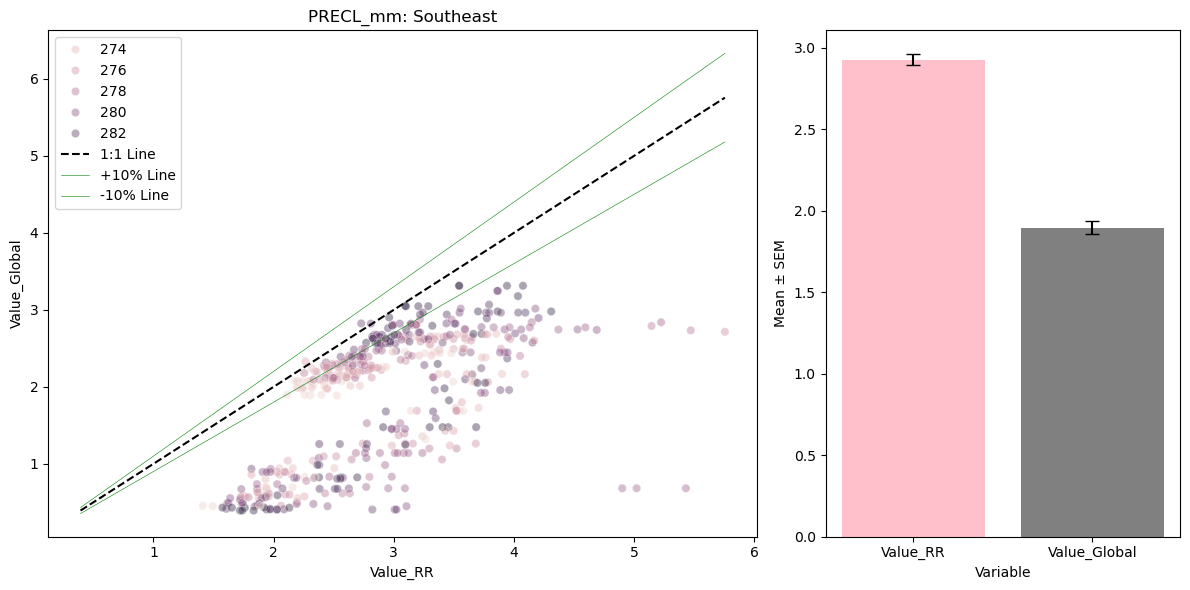

NRMSE = 0.45
R = 0.65


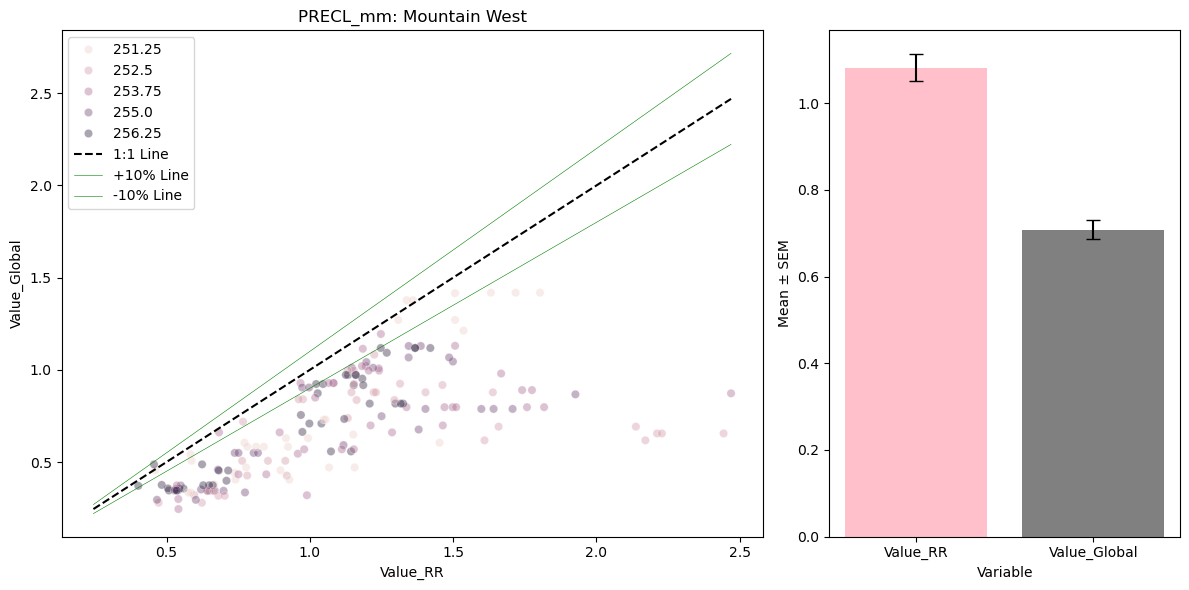

NRMSE = 0.56
R = 0.86


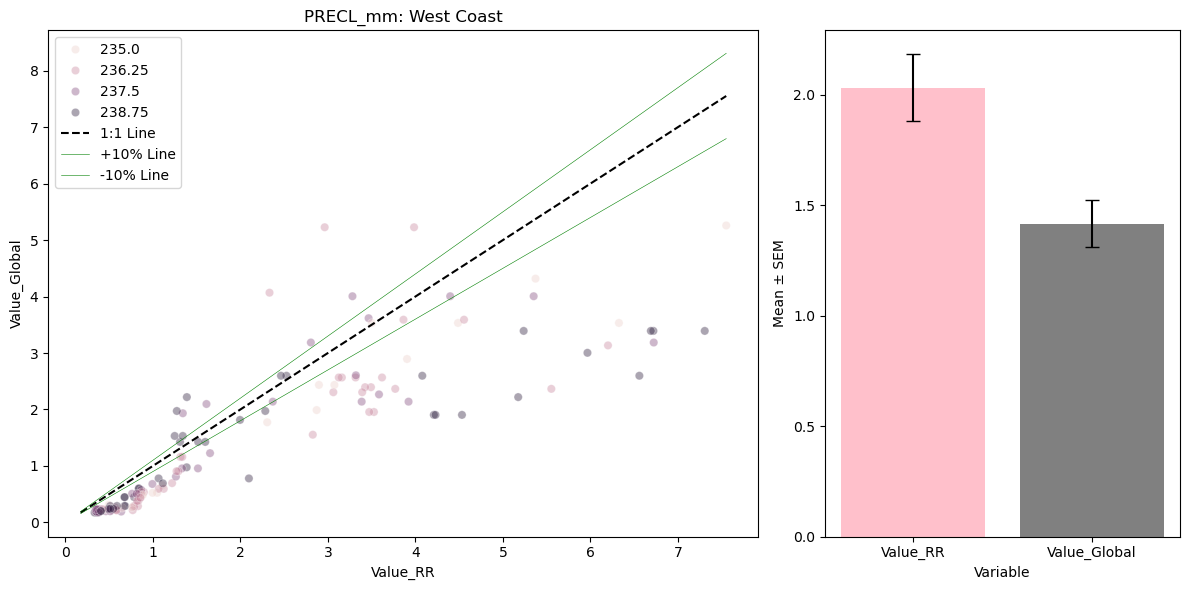

NRMSE = 0.35
R = 0.92


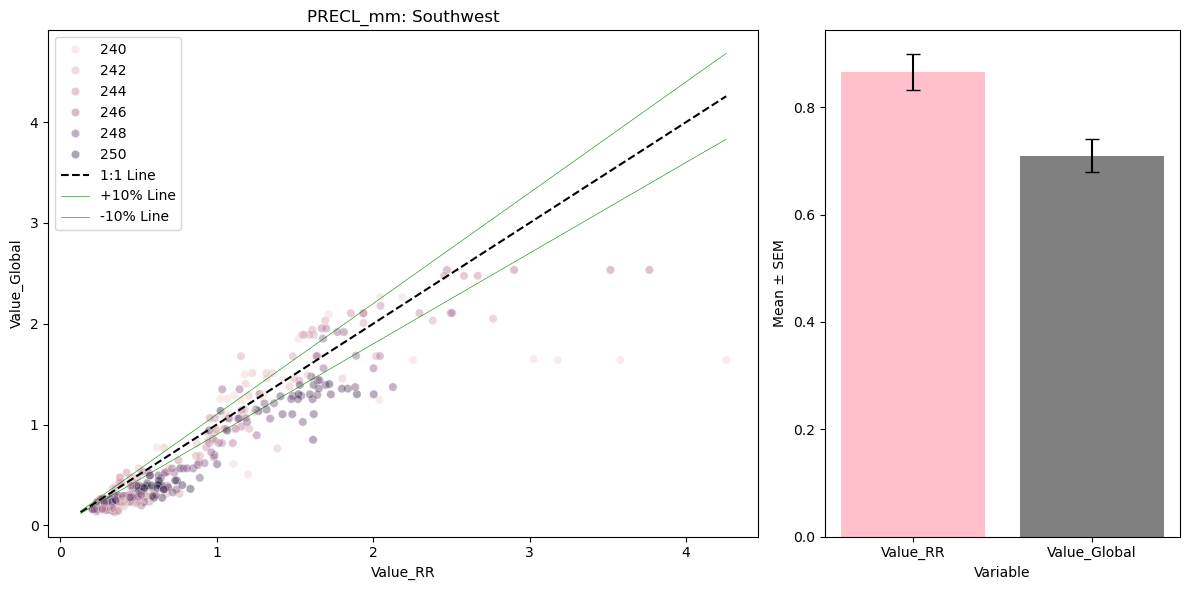

NRMSE = 1.4
R = 0.93


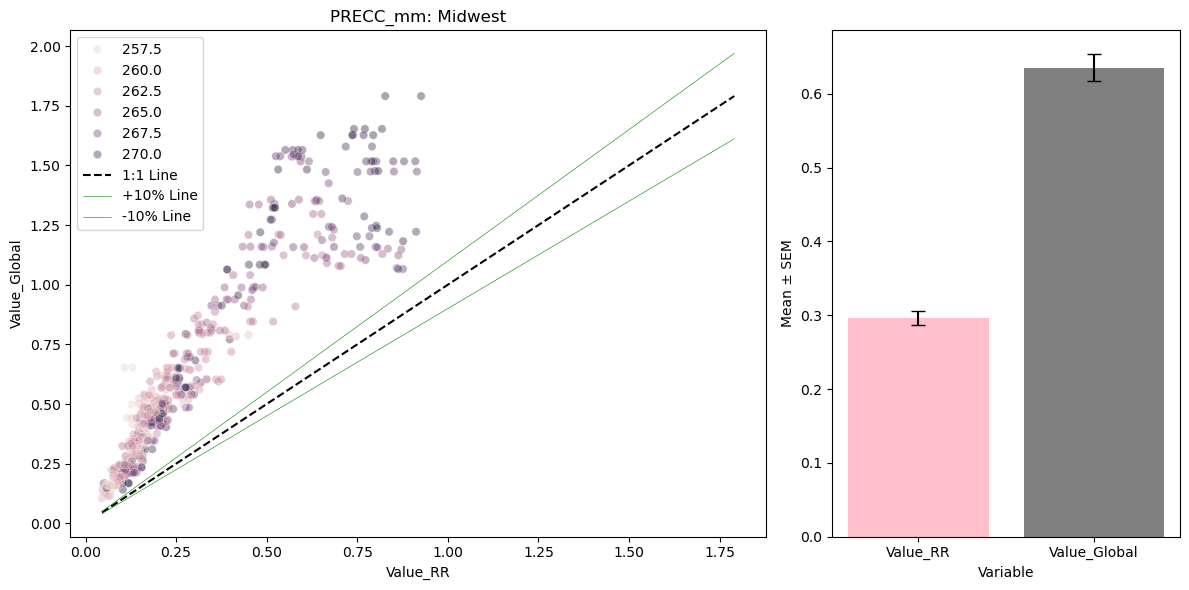

NRMSE = 1.1
R = 0.92


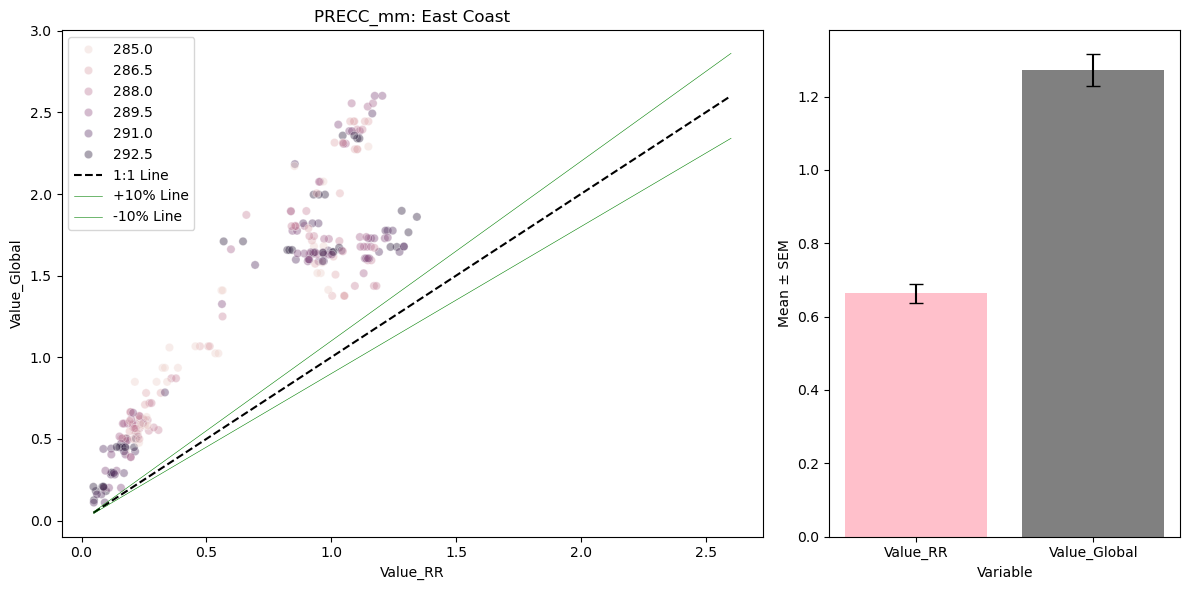

NRMSE = 1.2
R = 0.9


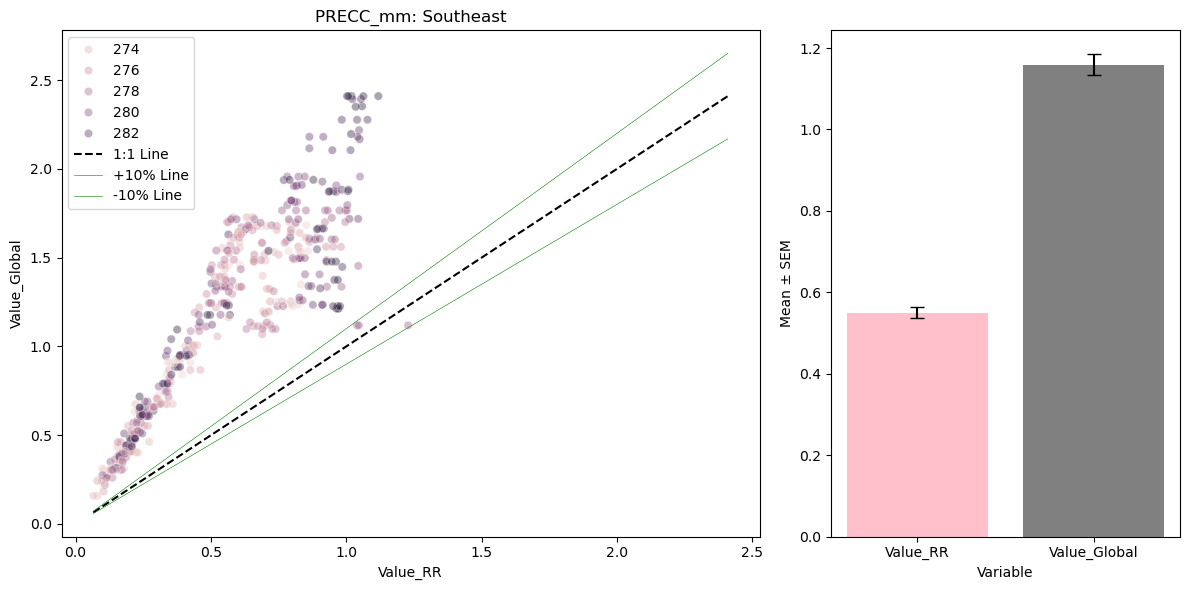

NRMSE = 2.6
R = 0.87


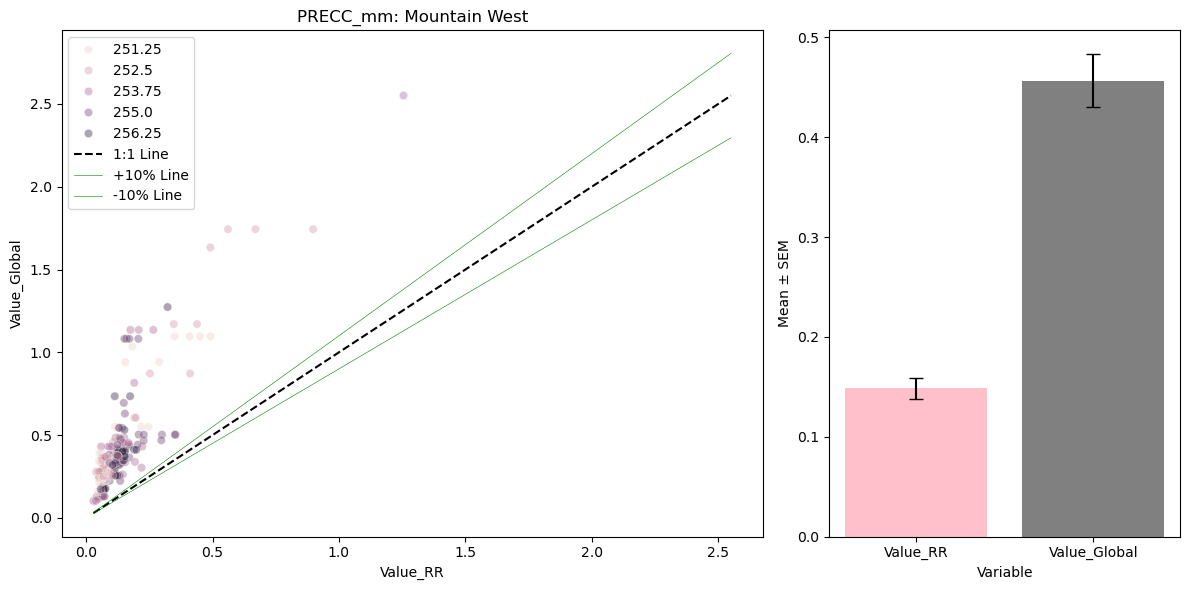

NRMSE = 1.6
R = 0.88


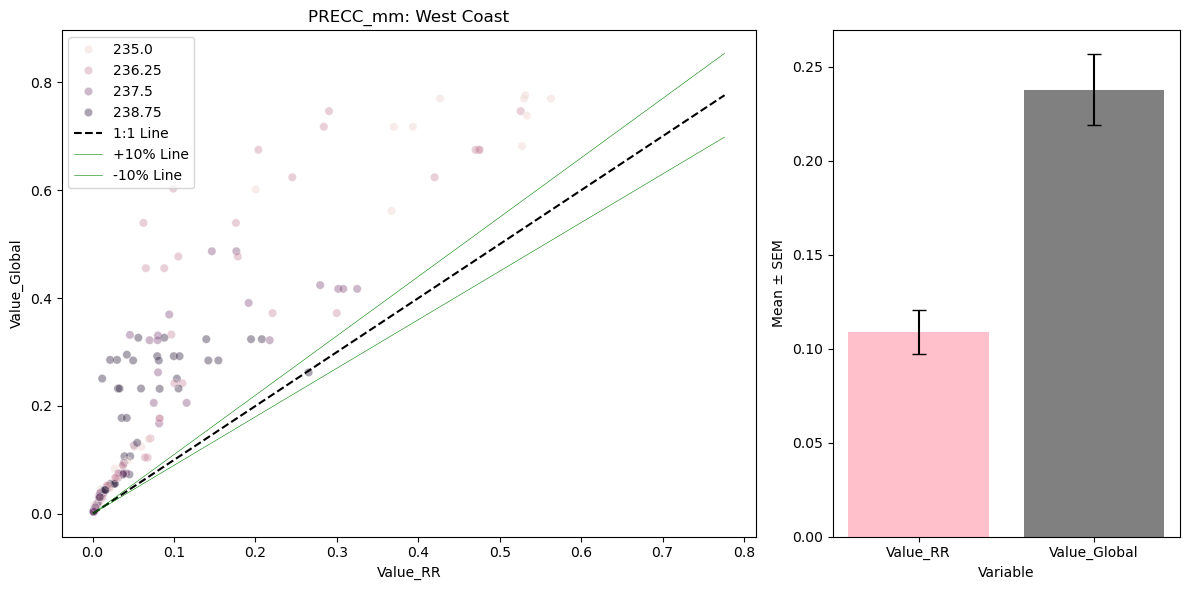

NRMSE = 3.3
R = 0.77


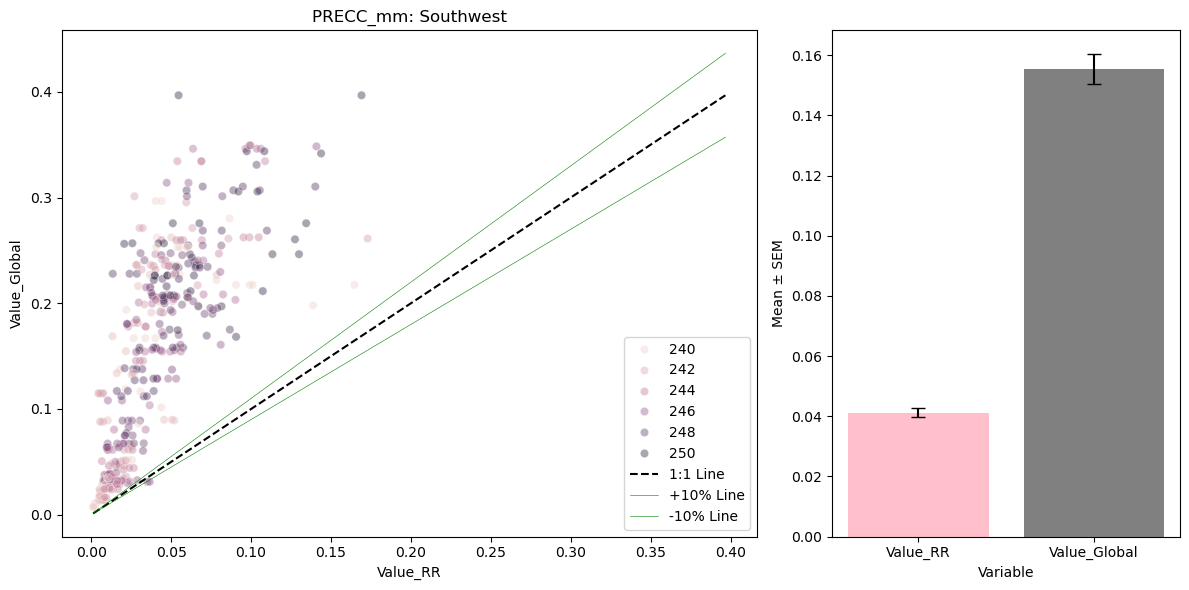

NRMSE = 0.26
R = 0.9


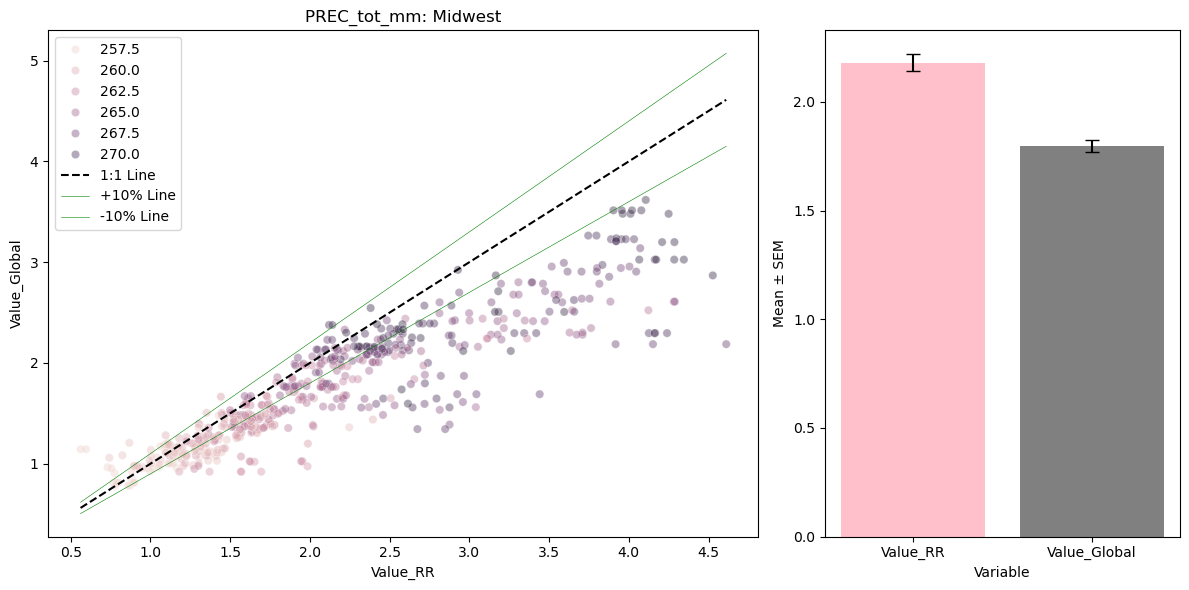

NRMSE = 0.19
R = 0.79


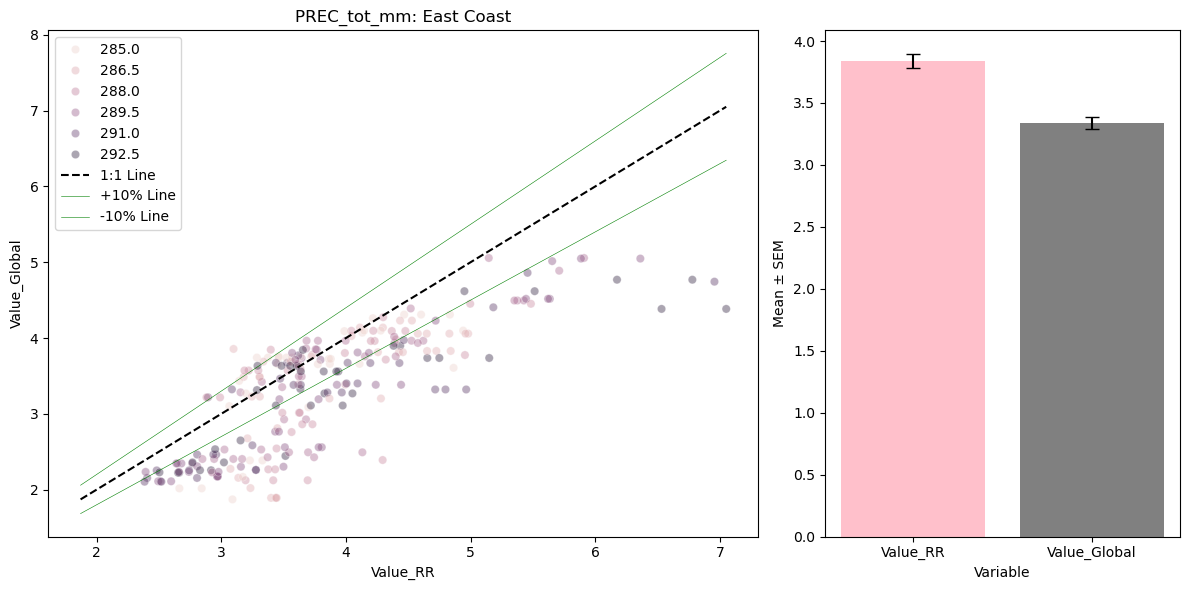

NRMSE = 0.21
R = 0.7


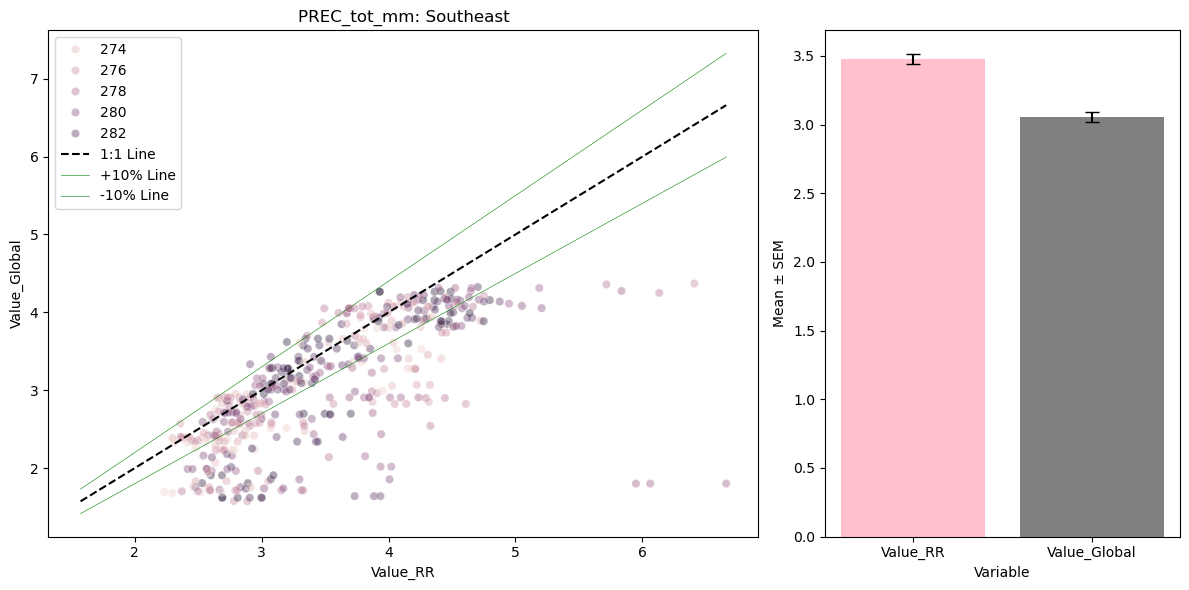

NRMSE = 0.27
R = 0.76


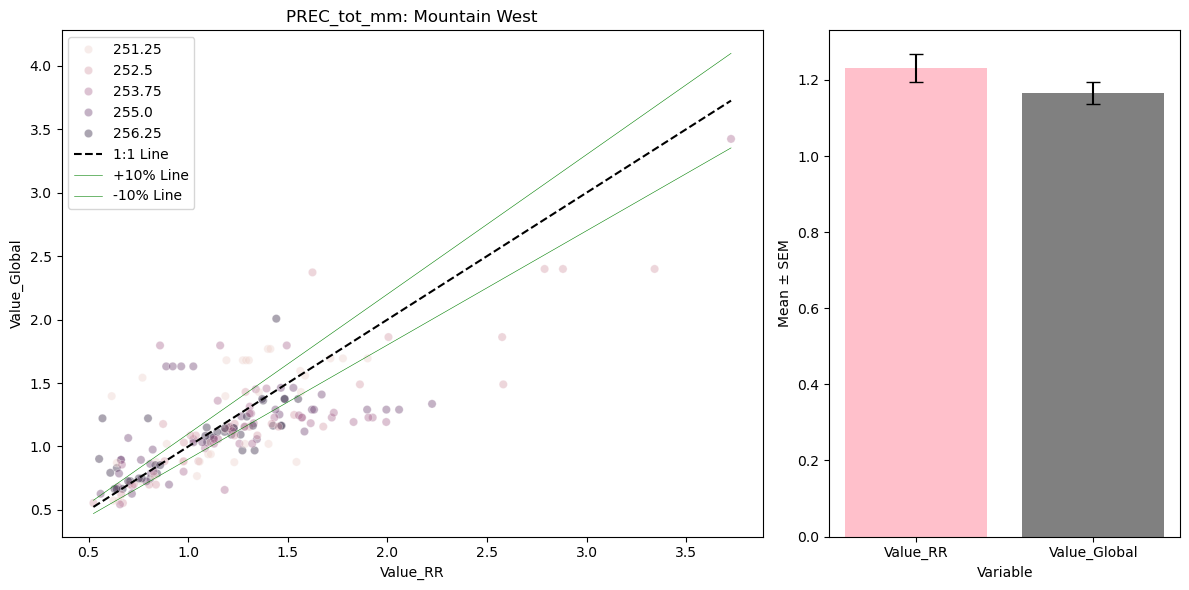

NRMSE = 0.5
R = 0.87


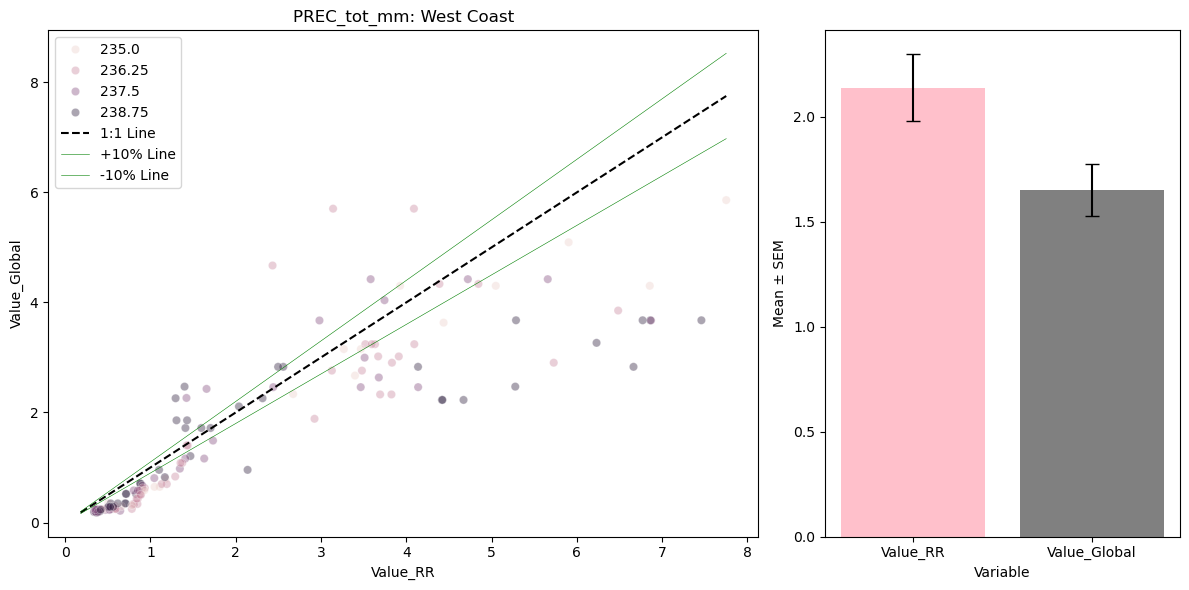

NRMSE = 0.31
R = 0.92


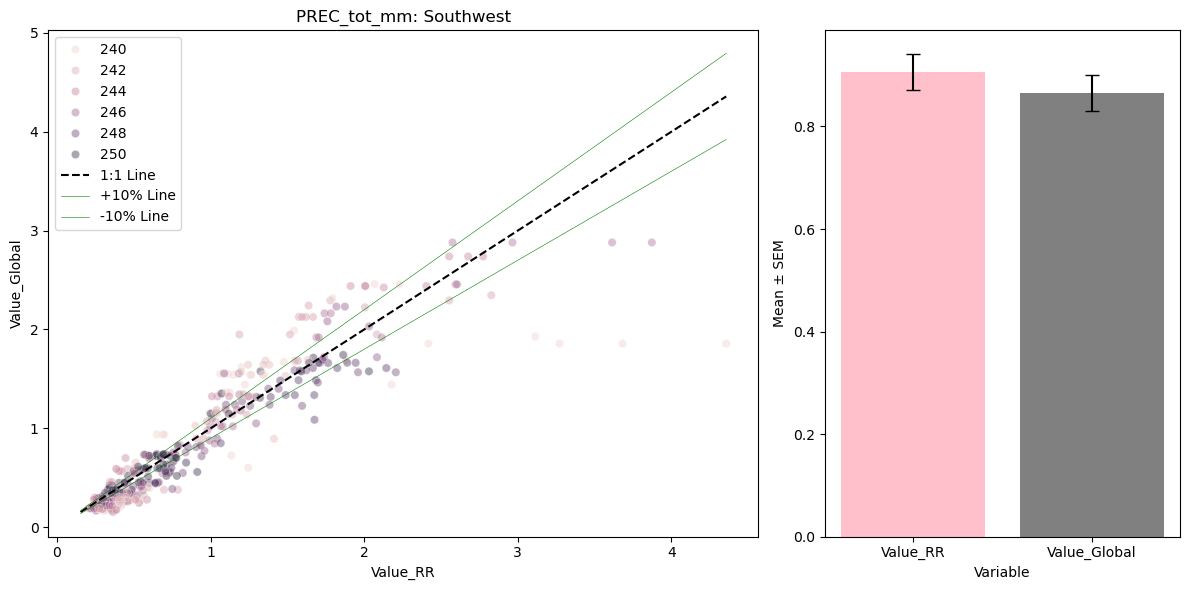

NRMSE = 0.15
R = 0.92


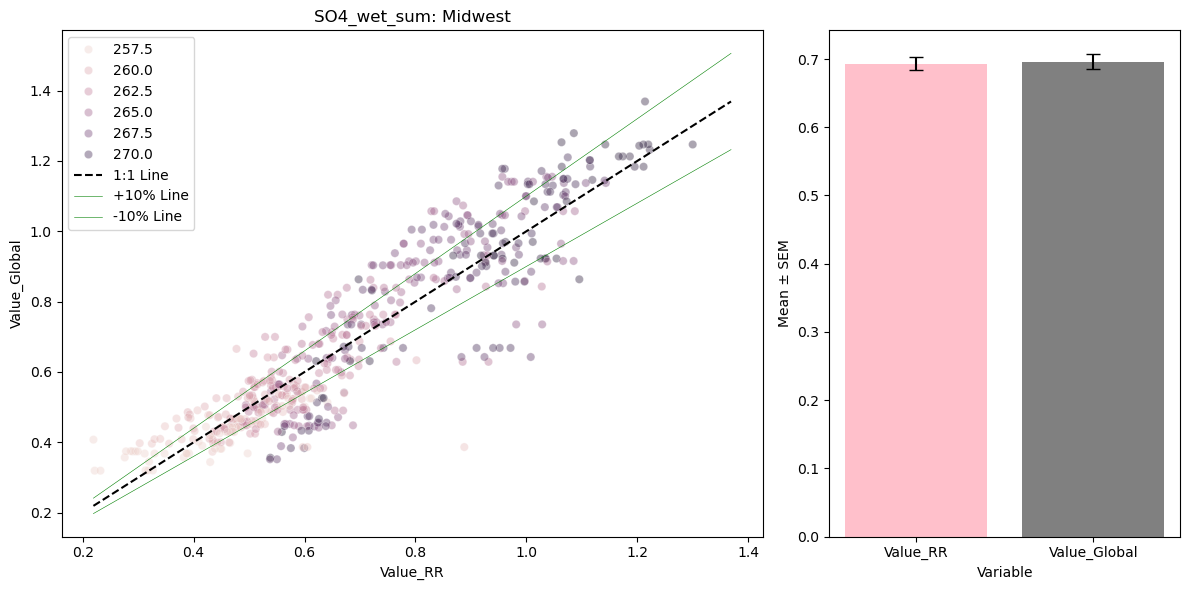

NRMSE = 0.15
R = 0.97


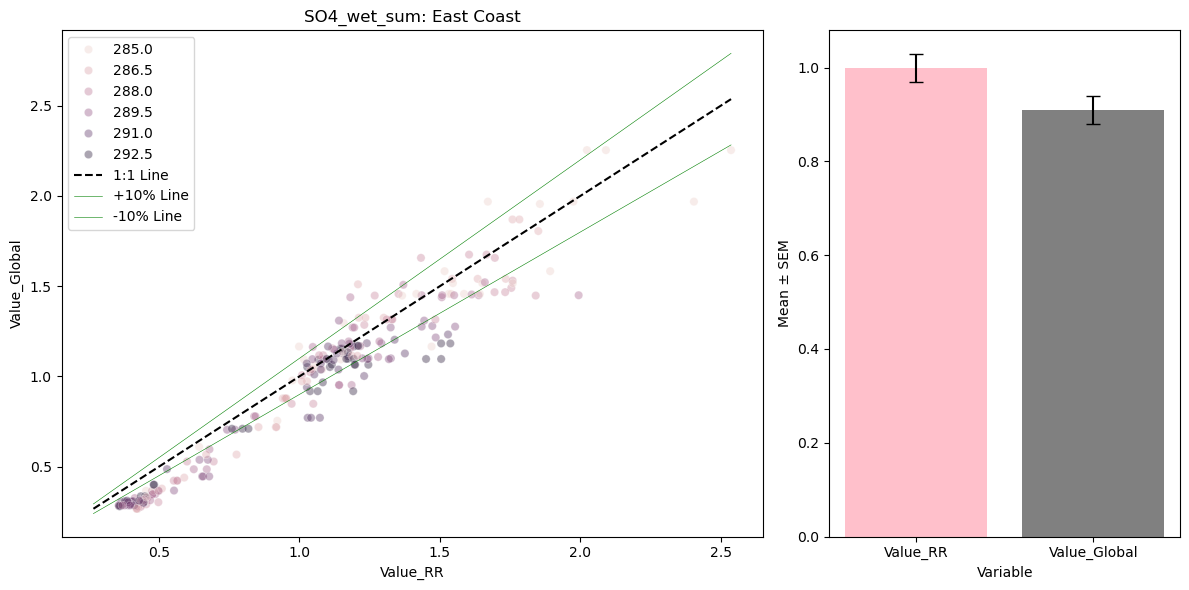

NRMSE = 0.15
R = 0.96


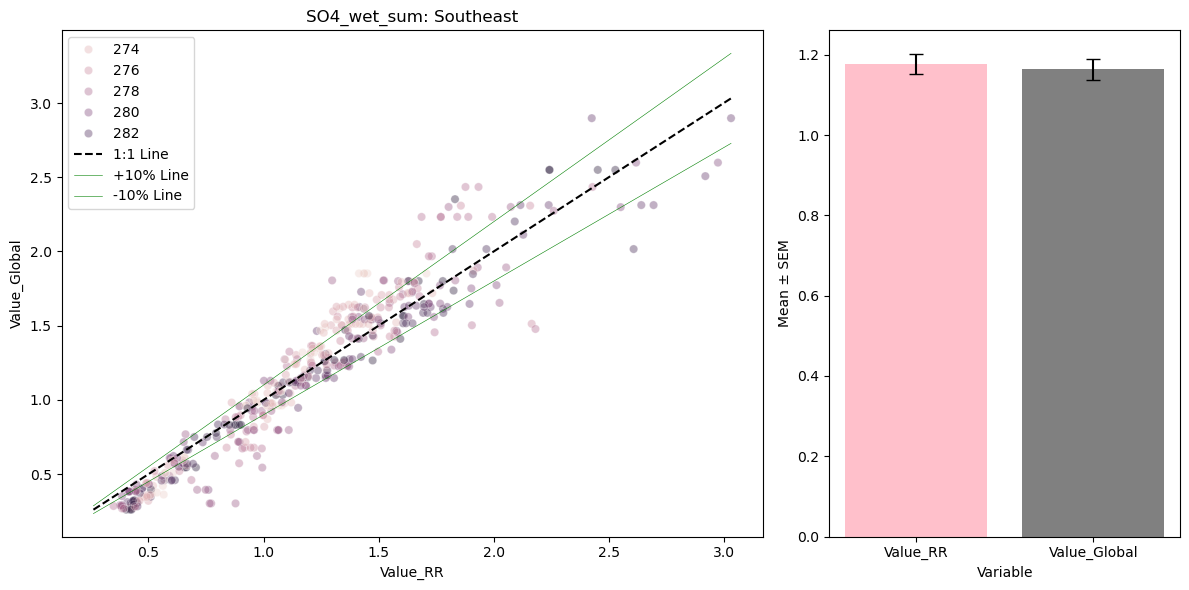

NRMSE = 0.27
R = 0.85


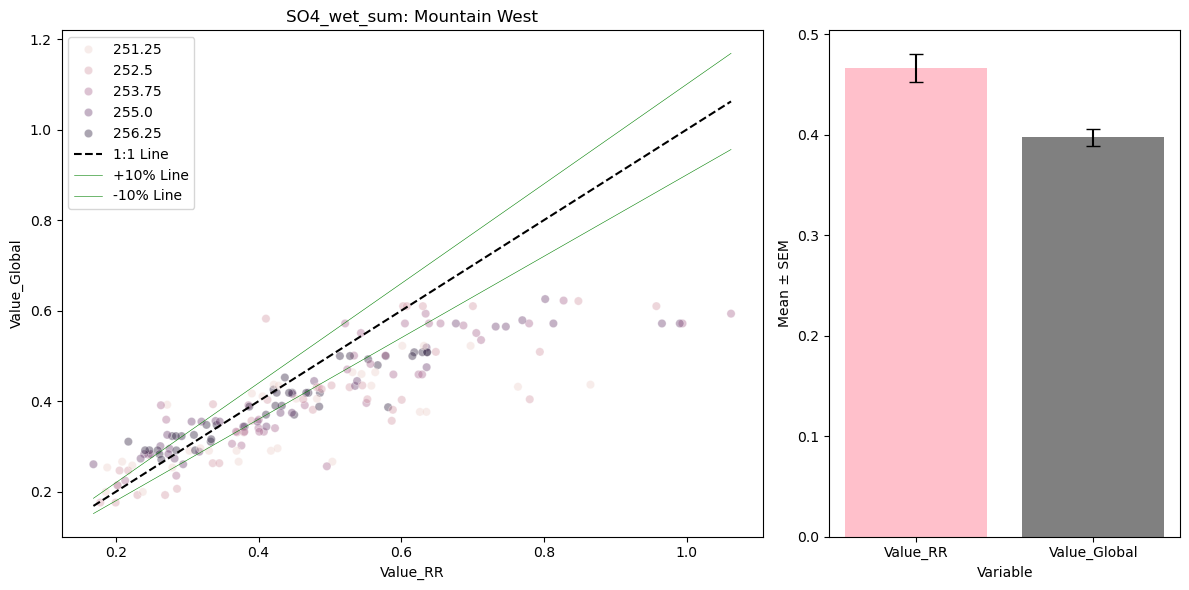

NRMSE = 0.58
R = 0.84


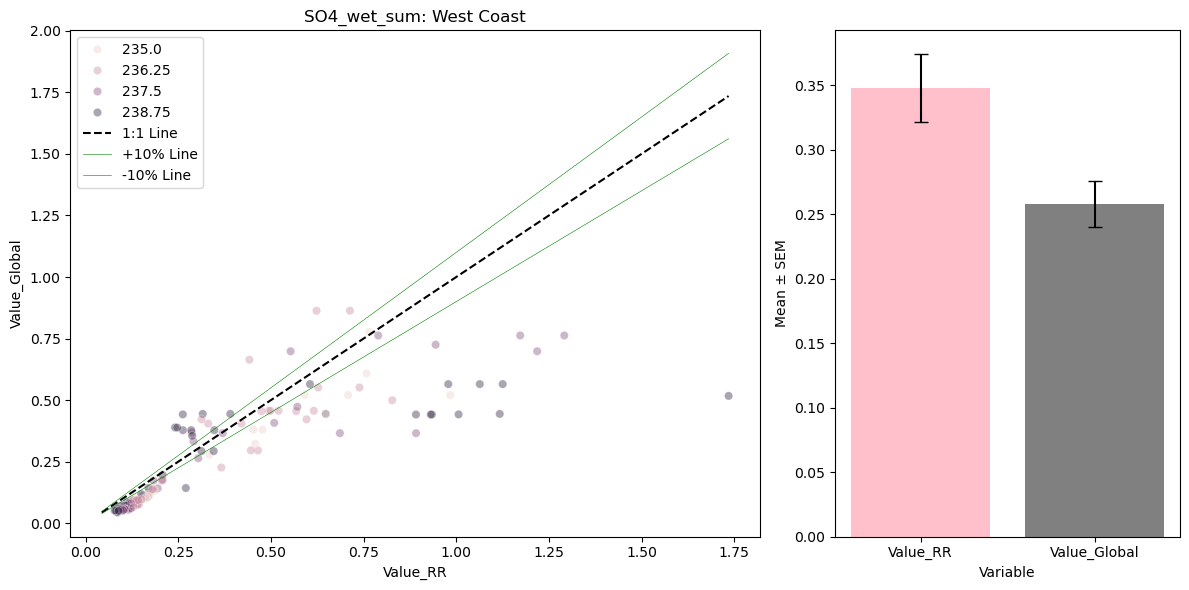

NRMSE = 0.38
R = 0.93


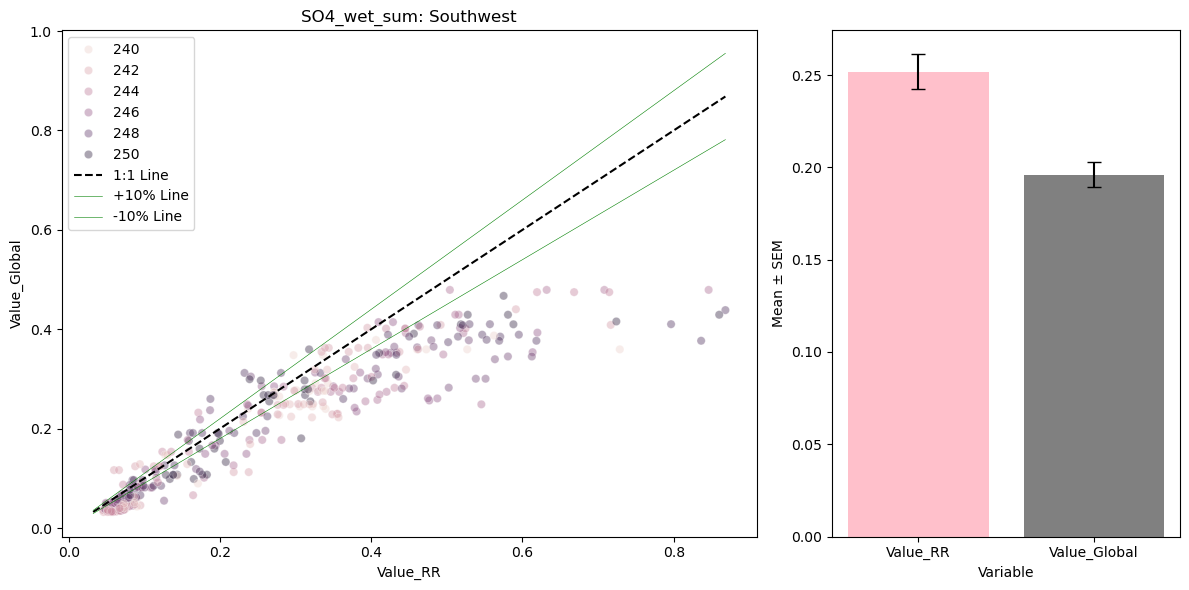

NRMSE = 0.23
R = 0.95


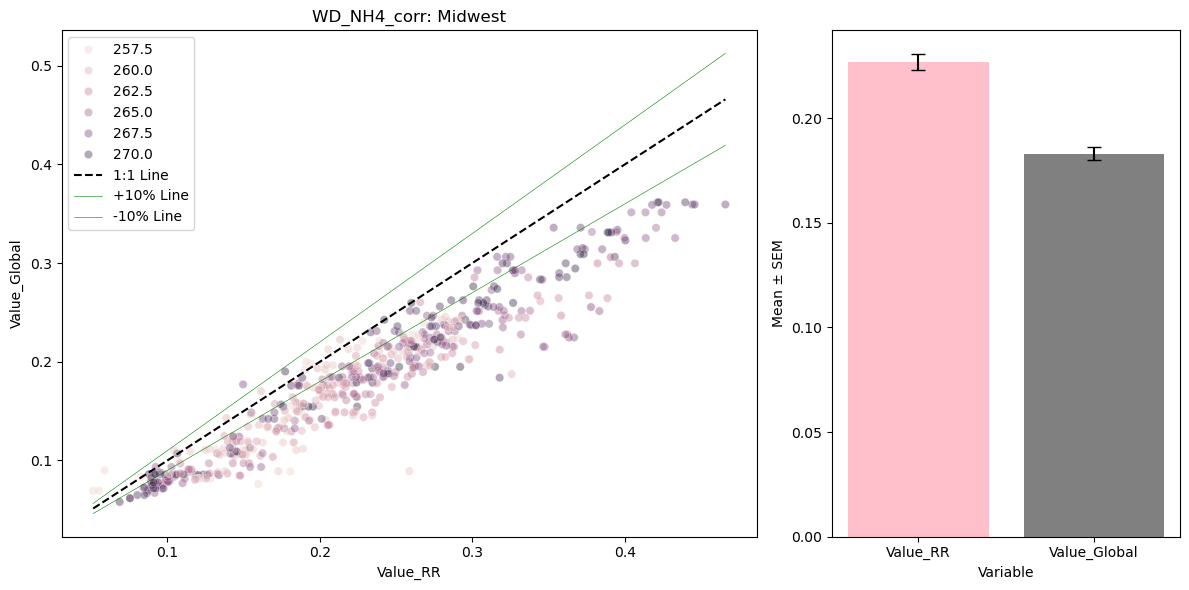

NRMSE = 0.22
R = 0.96


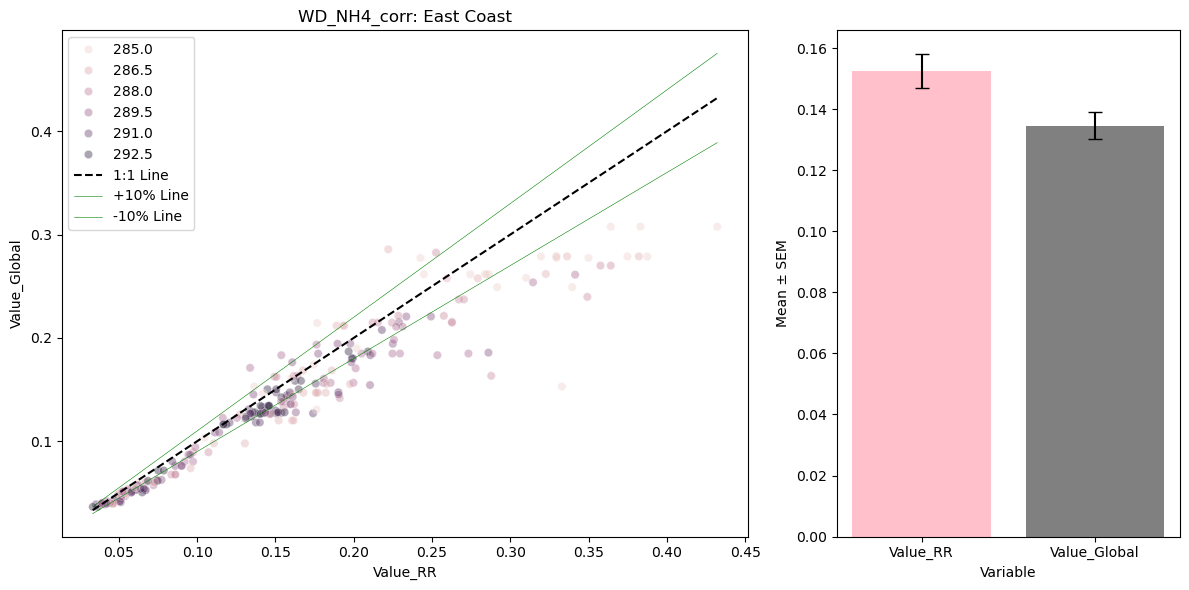

NRMSE = 0.23
R = 0.96


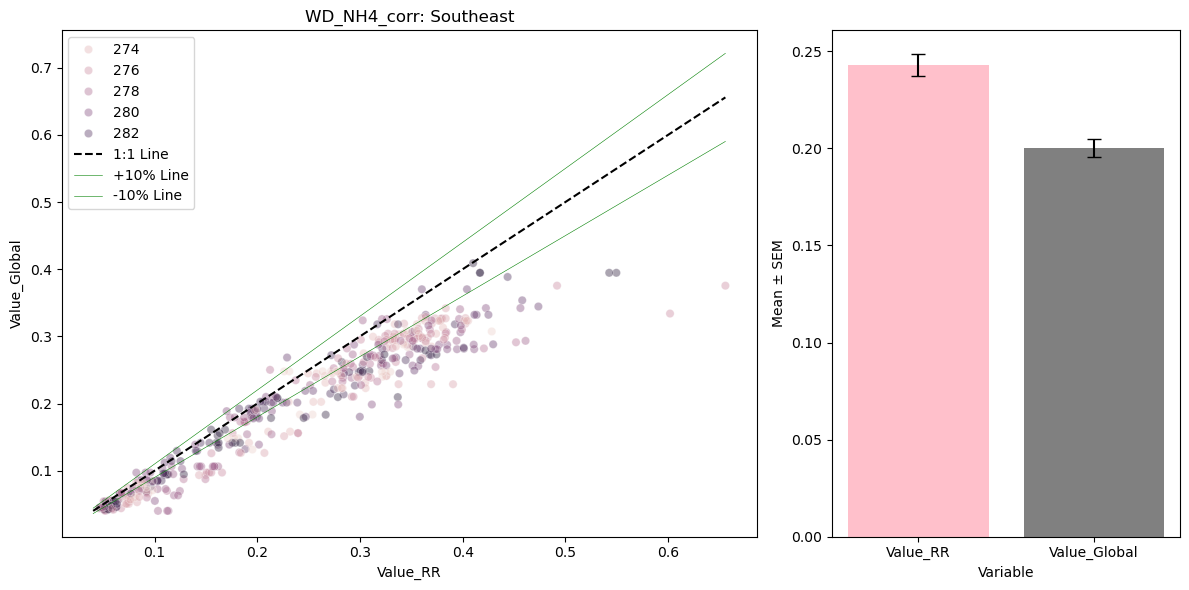

NRMSE = 0.44
R = 0.72


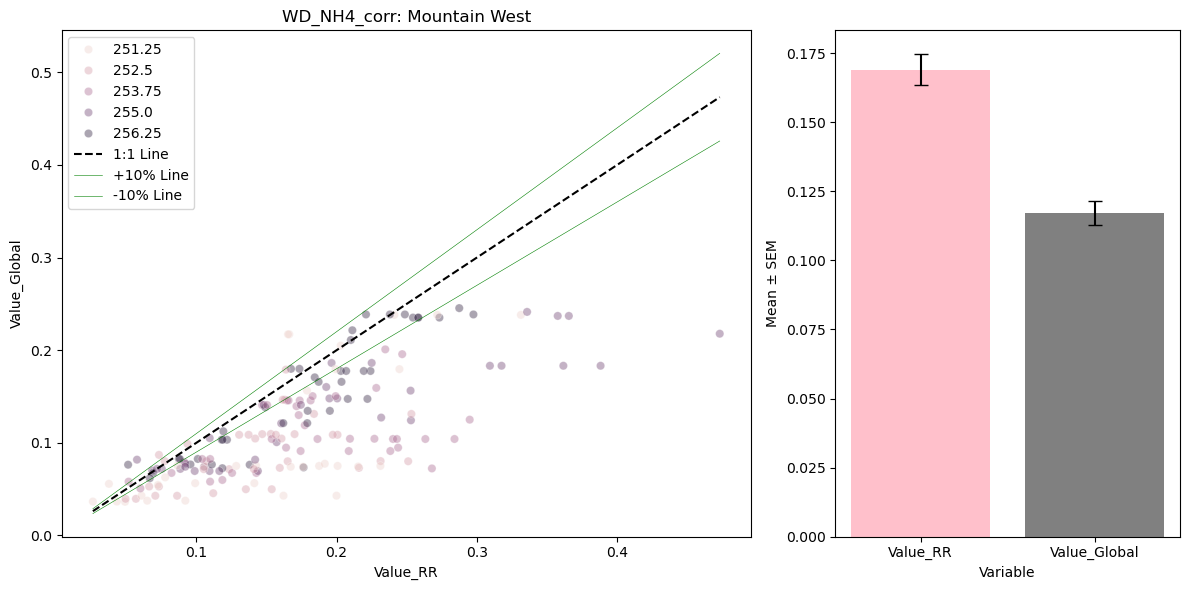

NRMSE = 0.69
R = 0.8


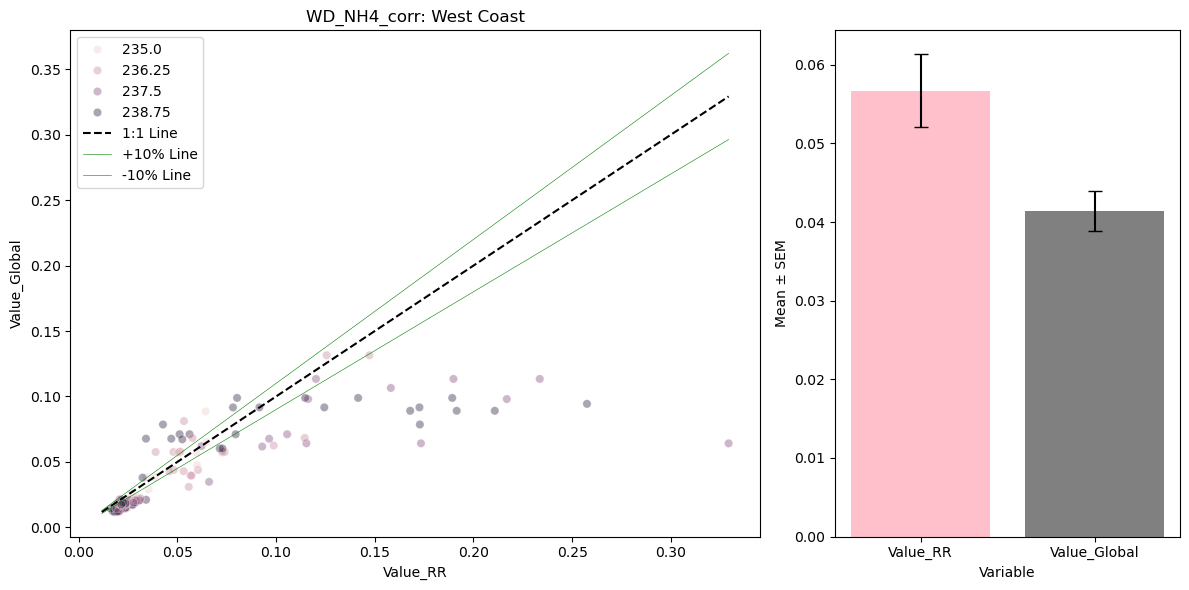

NRMSE = 0.56
R = 0.92


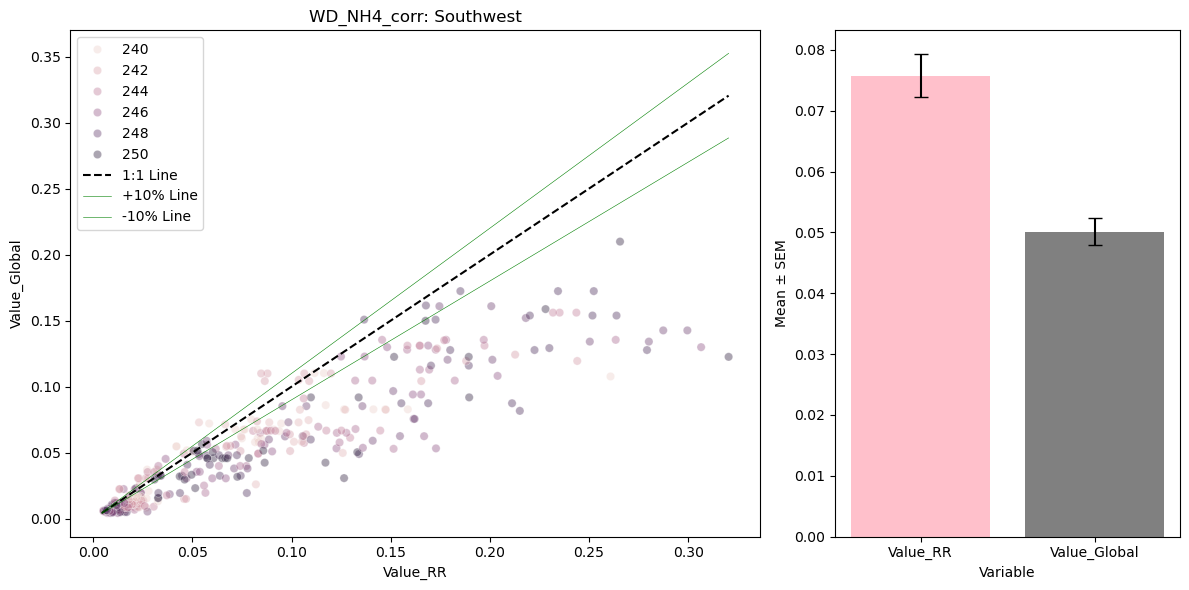

NRMSE = 0.15
R = 0.94


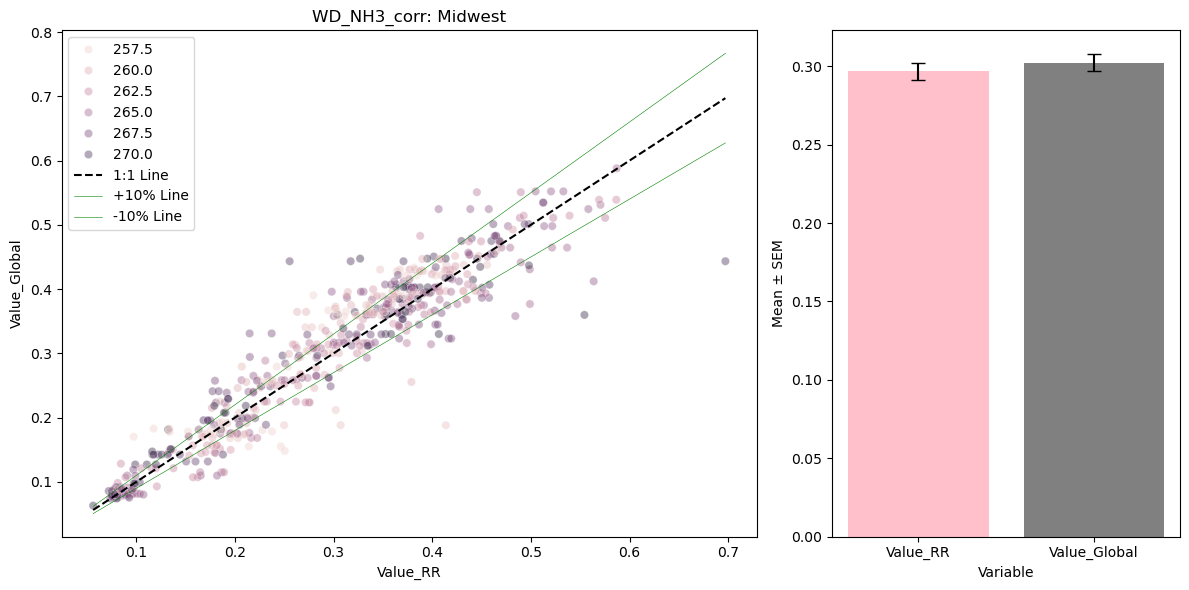

NRMSE = 0.34
R = 0.9


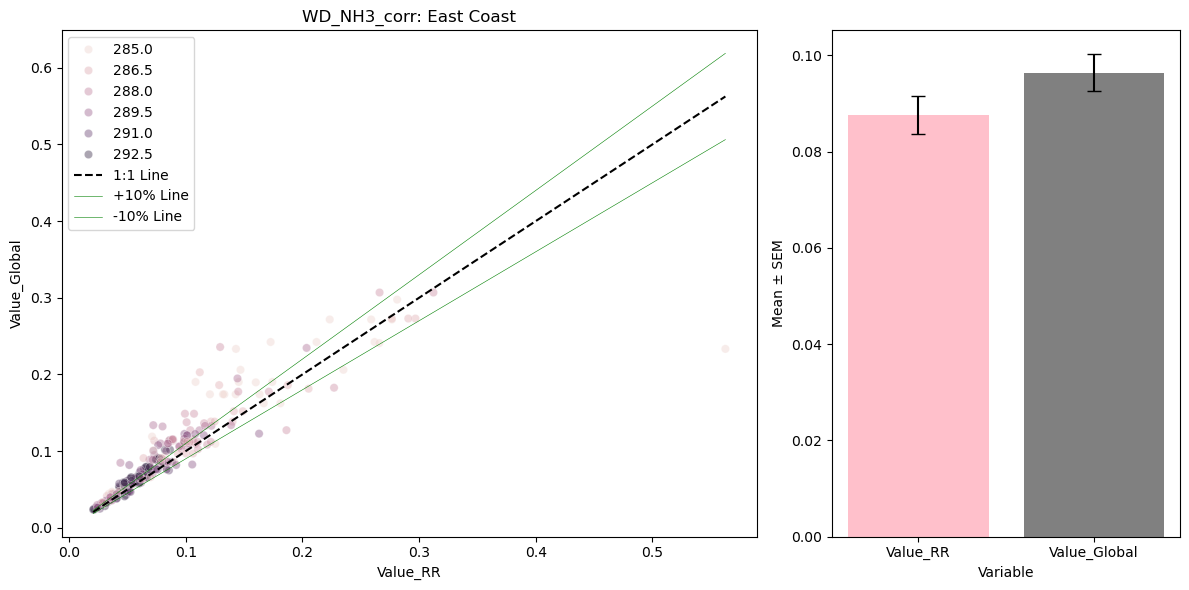

NRMSE = 0.22
R = 0.94


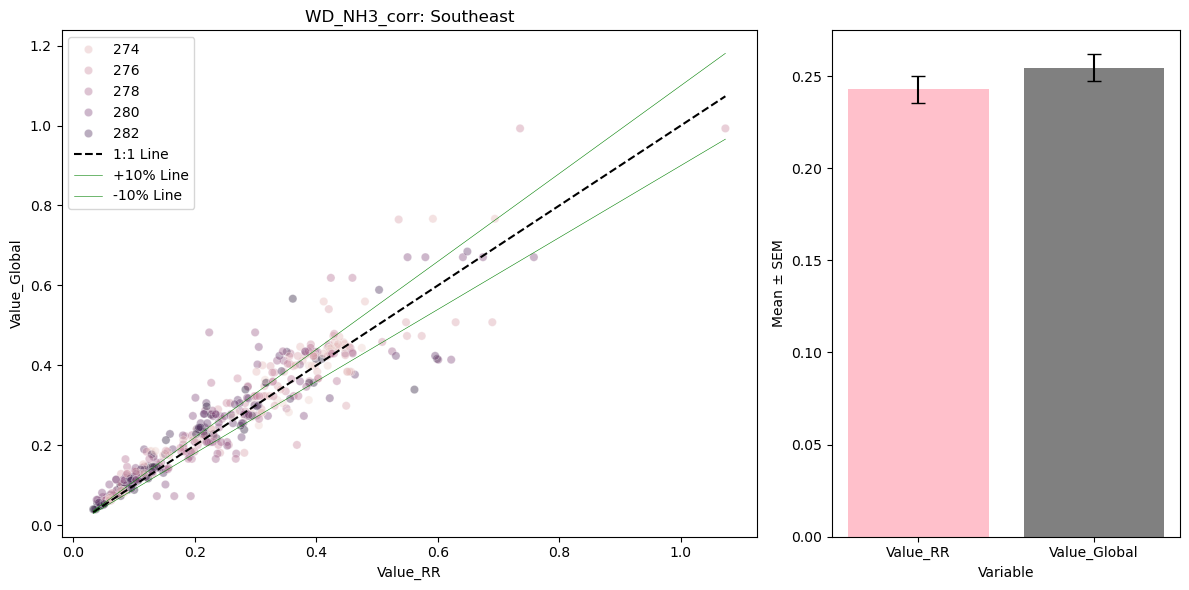

NRMSE = 0.26
R = 0.8


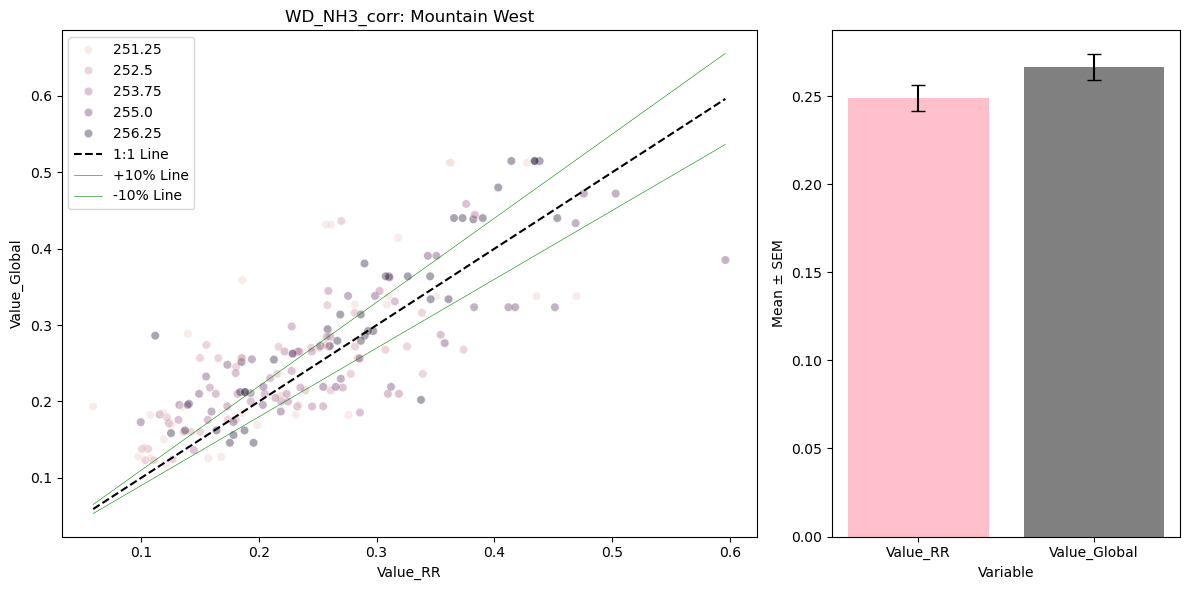

NRMSE = 0.5
R = 0.89


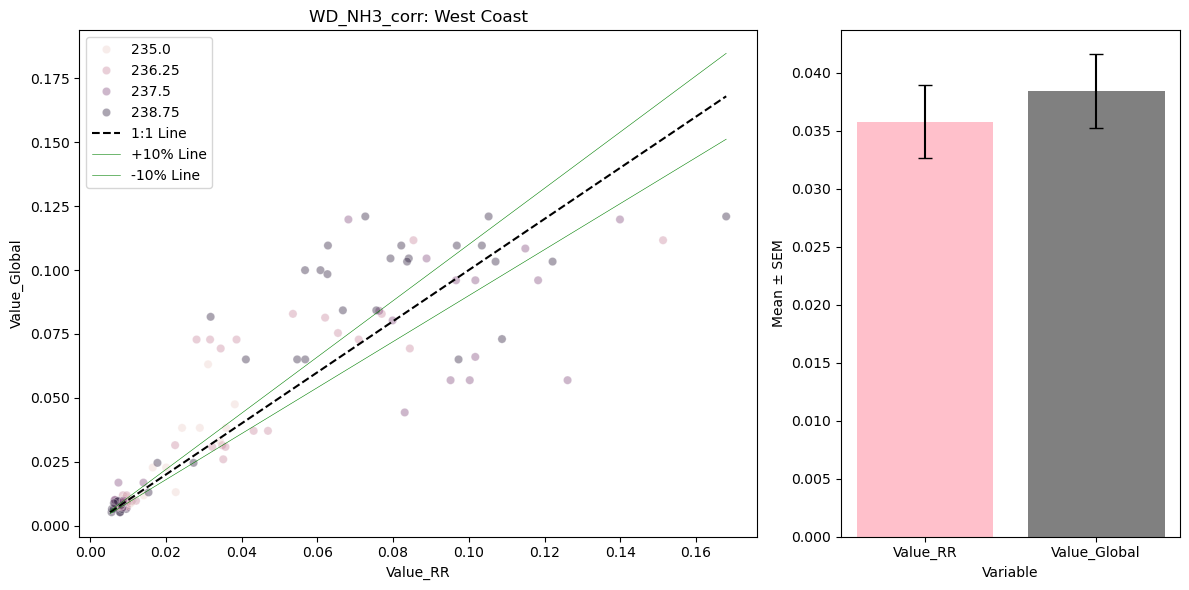

NRMSE = 0.36
R = 0.93


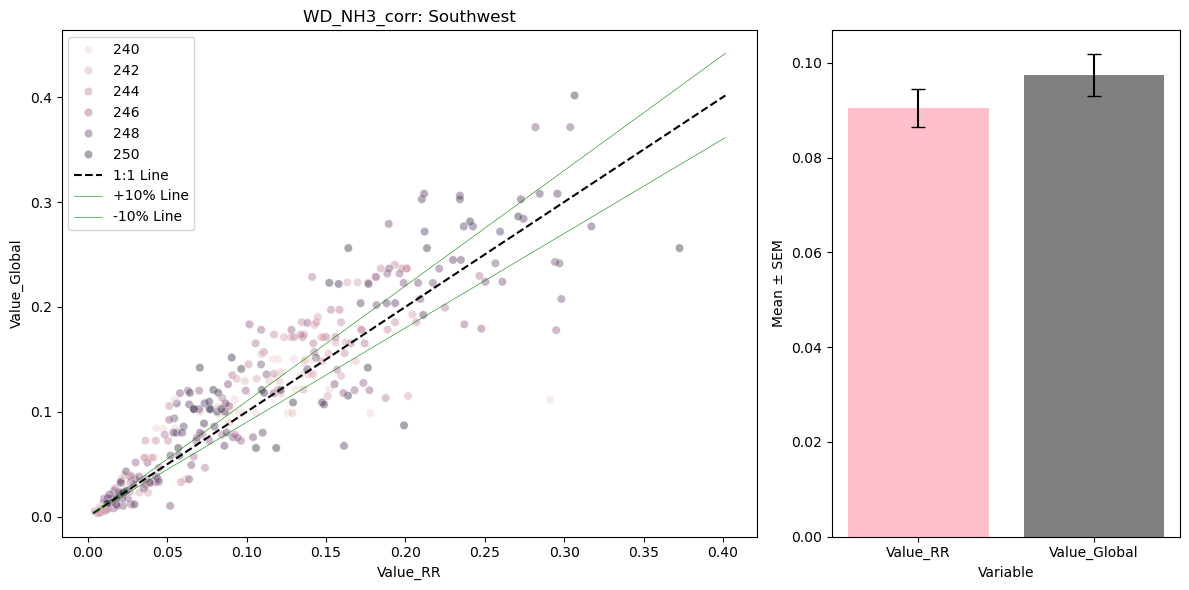

NRMSE = 0.18
R = 0.9


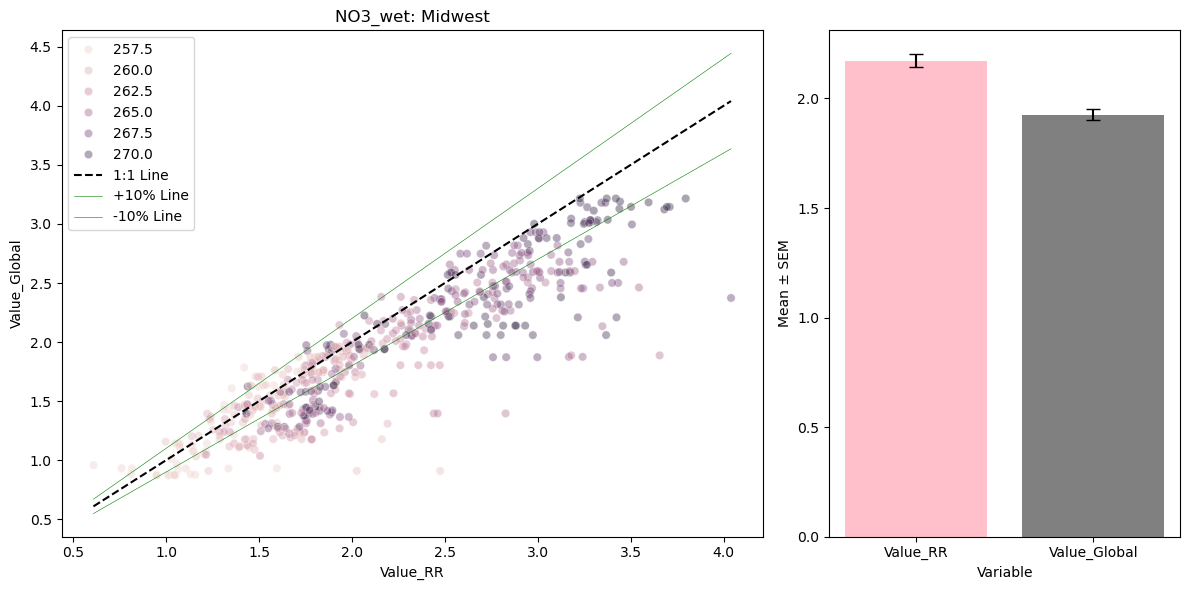

NRMSE = 0.17
R = 0.97


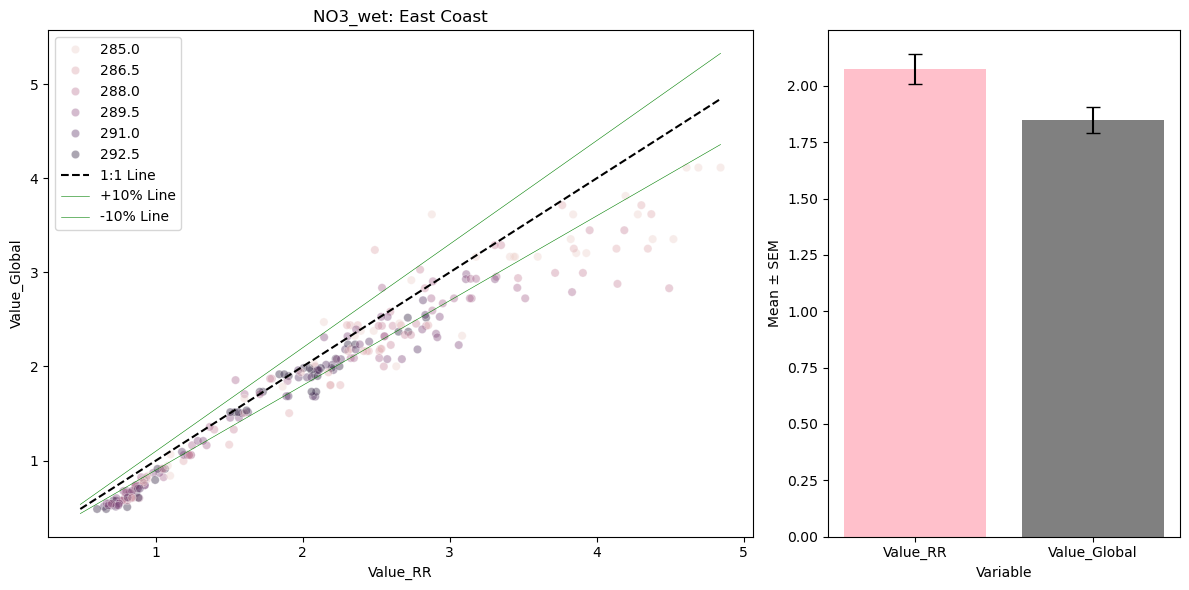

NRMSE = 0.17
R = 0.92


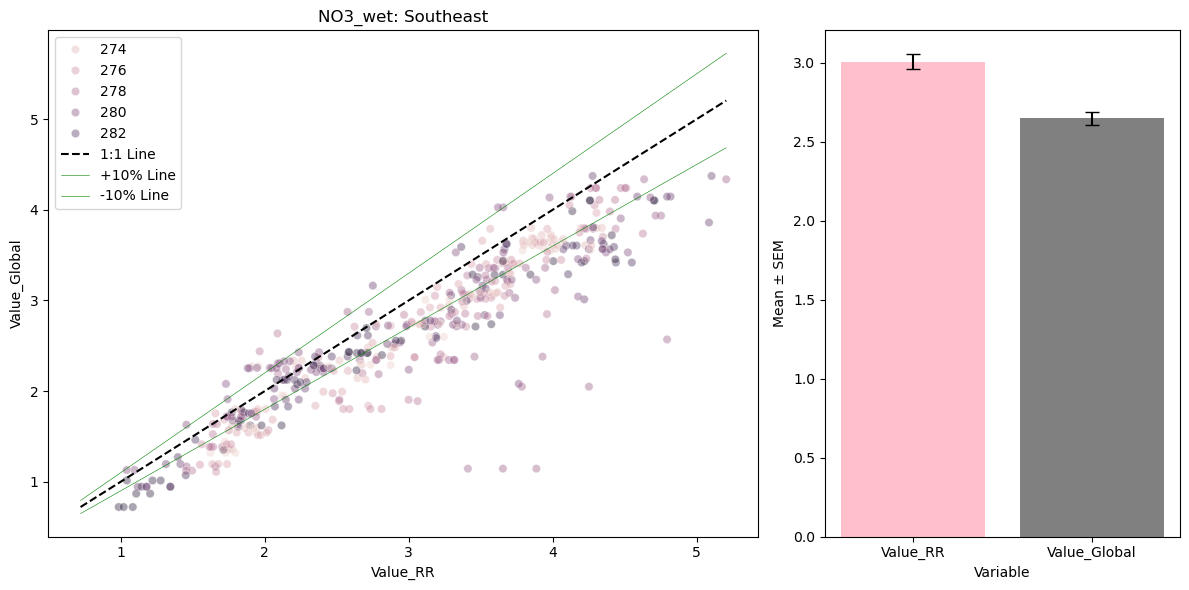

NRMSE = 0.26
R = 0.79


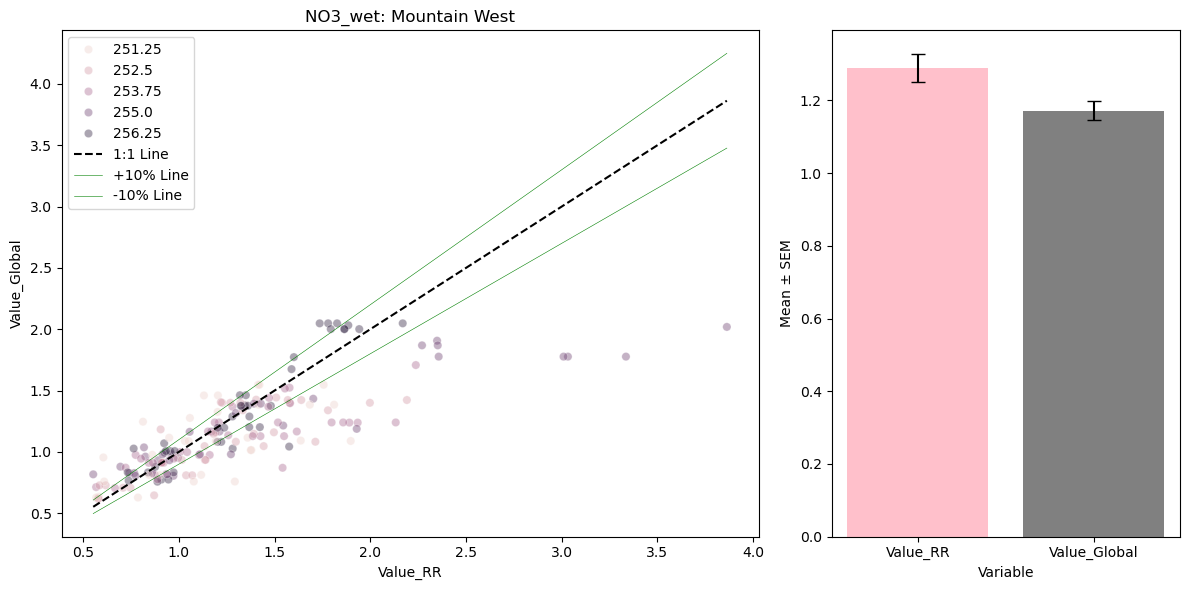

NRMSE = 0.58
R = 0.85


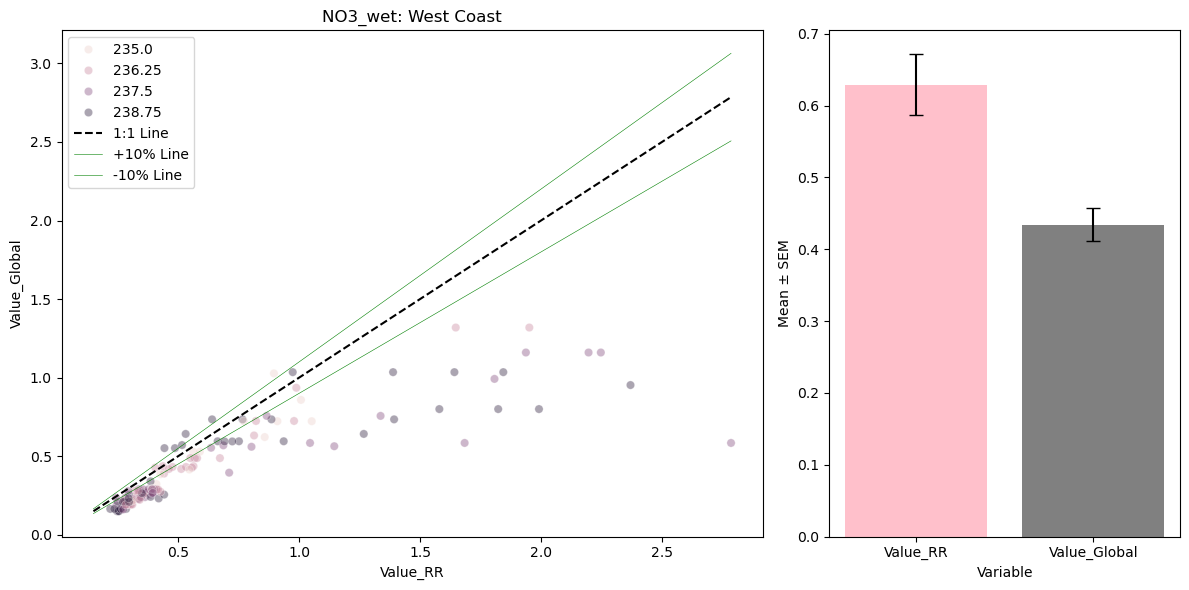

NRMSE = 0.33
R = 0.91


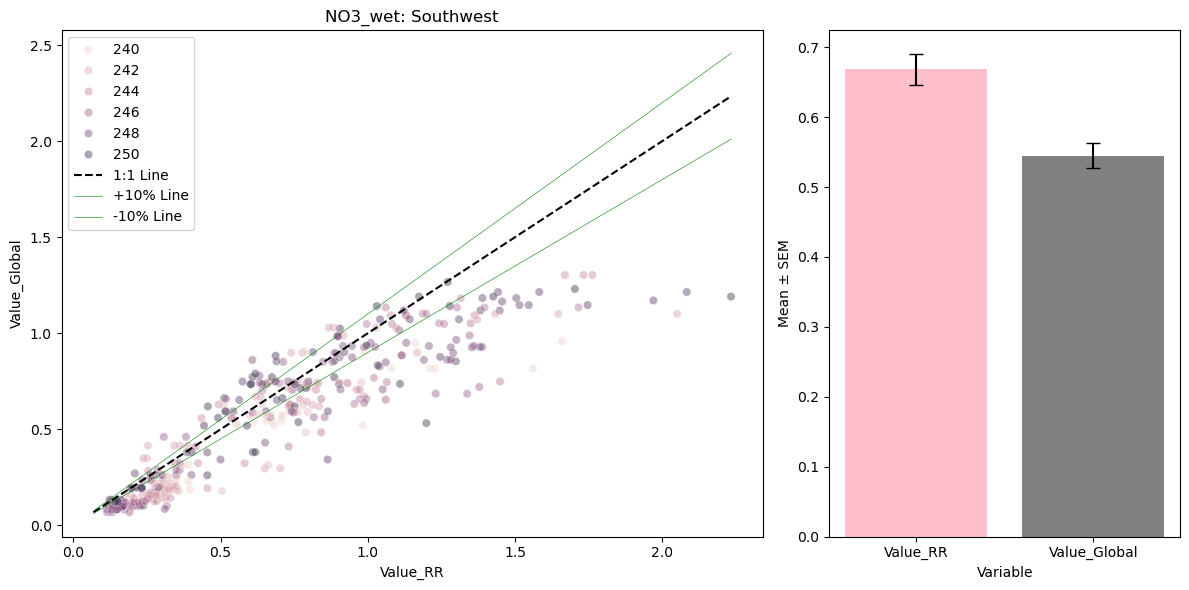

In [23]:
#Now can start to visualize and calculate statistics between these two dfs:

for i in df_mean_glob_RR.variable.unique():
    dat_var = df_mean_glob_RR.loc[df_mean_glob_RR.variable == i,]
    for j in dat_var.region.unique():
        dat_var_reg = dat_var.loc[dat_var.region == j,]
        dat_nrmse = nrmse(dat_var_reg['Value_RR'], dat_var_reg['Value_Global'])
        print(f"NRMSE = {dat_nrmse:.2g}")
        t_stat, p_value = stats.ttest_ind(dat_var_reg['Value_RR'], dat_var_reg['Value_Global'])
        r, p_value_r = pearsonr(dat_var_reg['Value_RR'], dat_var_reg['Value_Global'])
        print(f"R = {r:.2g}")
        
        # Prepare figure with 2 subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [2, 1]})
        
        # Panel 1: Scatter plot
        sns.scatterplot(data=dat_var_reg, x='Value_RR', y='Value_Global', hue='lon_glob', ax=axes[0], alpha = 0.4)
        min_val = min(min(dat_var_reg['Value_RR']), min(dat_var_reg['Value_Global']))
        max_val = max(max(dat_var_reg['Value_RR']), max(dat_var_reg['Value_Global']))
        axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')  # 1:1 line
        axes[0].plot([min_val, max_val], [1.1 * min_val, 1.1 * max_val], 'g', label='+10% Line', linewidth=0.4)  # +10%
        axes[0].plot([min_val, max_val], [0.9 * min_val, 0.9 * max_val], 'g', label='-10% Line', linewidth=0.4)  # -10%
        axes[0].set_title(f'{i}: {j}')
        axes[0].set_xlabel('Value_RR')
        axes[0].set_ylabel('Value_Global')
        axes[0].legend()
    
        # Panel 2: Mean values plot with error bars
        means = [dat_var_reg['Value_RR'].mean(), dat_var_reg['Value_Global'].mean()]
        errors = [dat_var_reg['Value_RR'].std() / np.sqrt(len(dat_var_reg['Value_RR'])),  # SEM for Value_RR
                  dat_var_reg['Value_Global'].std() / np.sqrt(len(dat_var_reg['Value_Global']))]  # SEM for Value_Global
        
        axes[1].bar(['Value_RR', 'Value_Global'], means, color=['pink', 'grey'], yerr=errors, capsize=5)
        axes[1].set_ylabel('Mean ± SEM')
        axes[1].set_xlabel('Variable')
        
        # Show the full figure
        plt.tight_layout()
        plt.savefig(f'/glade/u/home/demurray/External File Uploads/Figures/RR Global random comparison {i} {j}.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
        plt.show()

In [5]:
#Convective vs. large scale precipitation comparison in RR:
glob_RR_prec = df_mean_glob_RR[df_mean_glob_RR['variable'].isin(['PRECL_mm', 'PRECC_mm', 'PREC_tot_mm'])]
RR_prec = glob_RR_prec[['pointId', 'lat_RR', 'lon_RR', 'variable', 'Value_RR', 'region']]
RR_prec =RR_prec.pivot(index=['pointId', 'lat_RR', 'lon_RR','region'], columns = 'variable').reset_index()
RR_prec[('Value_RR', 'Convective_percent_RR')] = (RR_prec[('Value_RR','PRECC_mm')]/RR_prec[('Value_RR','PREC_tot_mm')])*100
RR_prec[('Value_RR', 'LargeScale_percent_RR')] = (RR_prec[('Value_RR','PRECL_mm')]/RR_prec[('Value_RR','PREC_tot_mm')])*100
RR_prec

pointId     lat_RR      lon_RR         region  Value_RR            \
variable                                                PRECC_mm  PRECL_mm   
0              0  31.505172  268.791112        Midwest  0.583089  3.215869   
1              1  48.877583  265.042362        Midwest  0.094069  1.442212   
2              2  37.959806  285.652704     East Coast  0.535693  3.335223   
3              3  32.208982  271.321205        Midwest  0.610927  3.674622   
4              4  47.585893  264.984519        Midwest  0.109076  1.665744   
...          ...        ...         ...            ...       ...       ...   
1995        1995  41.070222  268.828480        Midwest  0.212567  2.164269   
1996        1996  36.849583  278.070650      Southeast  0.585294  3.952495   
1997        1997  32.487582  290.573143     East Coast  0.865533  2.596701   
1998        1998  44.646453  244.542656      Southwest  0.099568  2.505099   
1999        1999  32.710396  256.151395  Mountain West  0.104666  0.535195   

                                                                  
variable PREC_tot_mm Convective_percent_RR LargeScale_percent_RR  
0           3.798957             15.348645             84.651355  
1           1.536281              6.123173             93.876827  
2           3.870917             13.838929             86.161071  
3           4.285549             14.255519             85.744481  
4           1.774820              6.145763             93.854237  
...              ...                   ...                   ...  
1995        2.376836              8.943272             91.056728  
1996        4.537788             12.898214             87.101786  
1997        3.462234             24.999254             75.000746  
1998        2.604667              3.822658             96.177342  
1999        0.639861             16.357563             83.642437  

[2000 rows x 9 columns]

In [6]:
#write some summary stats:
print(RR_prec[('Value_RR','Convective_percent_RR')].mean())
print(RR_prec[('Value_RR','LargeScale_percent_RR')].mean())

RR_prec_region = RR_prec.groupby('region').mean().reset_index()
RR_prec_region 

12.076505291920691
87.9234947080793


/glade/derecho/scratch/demurray/tmp/ipykernel_20146/964376329.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  RR_prec_region = RR_prec.groupby('region').mean().reset_index()
/glade/derecho/scratch/demurray/tmp/ipykernel_20146/964376329.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  RR_prec_region = RR_prec.groupby('region').mean().reset_index()


region      pointId     lat_RR      lon_RR  Value_RR  \
variable                                                     PRECC_mm   
0            West Coast  1076.560811  36.966443  237.181261  0.108943   
1             Southwest  1006.522277  36.119484  245.010308  0.041225   
2         Mountain West   976.750000  36.896565  253.862756  0.148583   
3               Midwest   962.136784  36.849810  264.351455  0.296217   
4             Southeast  1042.750000  37.061474  278.154143  0.549887   
5            East Coast   961.235521  36.706434  288.804587  0.663942   

                                                                            
variable  PRECL_mm PREC_tot_mm Convective_percent_RR LargeScale_percent_RR  
0         2.031044    2.139987              4.140823             95.859177  
1         0.864967    0.906192              5.069157             94.930843  
2         1.082152    1.230735             12.164881             87.835119  
3         1.882998    2.179215             13.113104             86.886896  
4         2.924932    3.474819             15.945043             84.054957  
5         3.174198    3.838139             18.383020             81.616980

<function matplotlib.pyplot.show(close=None, block=None)>

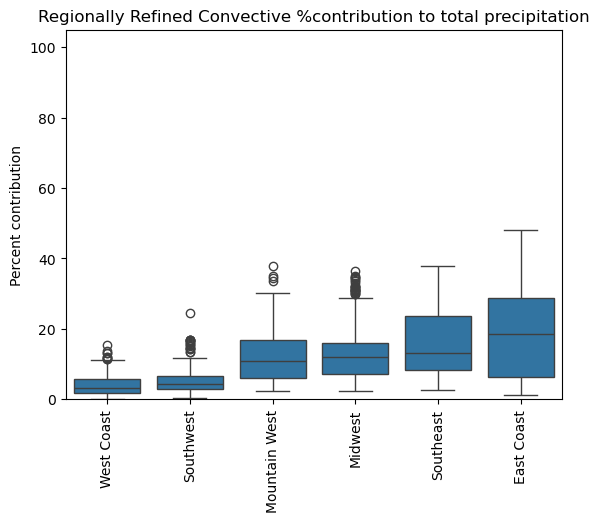

In [62]:
#plot these results
sns.boxplot(data = RR_prec, x = 'region', y = ('Value_RR','Convective_percent_RR'))
plt.tick_params(axis='x', rotation=90)
plt.ylim(0,105)
plt.title('Regionally Refined Convective %contribution to total precipitation')
plt.ylabel('Percent contribution')
plt.xlabel('')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

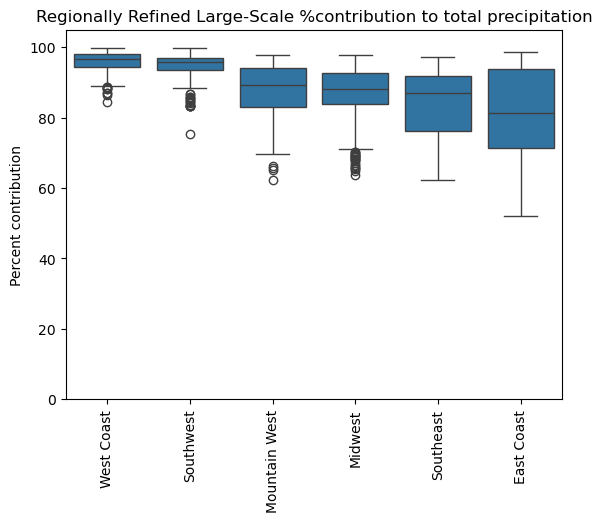

In [61]:
sns.boxplot(data = RR_prec, x = 'region', y = ('Value_RR','LargeScale_percent_RR'))
plt.tick_params(axis='x', rotation=90)
plt.ylim(0,105)
plt.title('Regionally Refined Large-Scale %contribution to total precipitation')
plt.ylabel('Percent contribution')
plt.xlabel('')
plt.show


In [8]:
#Convective vs. large scale precipitation comparison in Global:
glob_prec = glob_RR_prec[['pointId', 'lat_glob', 'lon_glob', 'variable', 'Value_Global', 'region']]
glob_prec =glob_prec.pivot(index=['pointId', 'lat_glob', 'lon_glob','region'], columns = 'variable').reset_index()
glob_prec[('Value_Global', 'Convective_percent_glob')] = (glob_prec[('Value_Global','PRECC_mm')]/glob_prec[('Value_Global','PREC_tot_mm')])*100
glob_prec[('Value_Global', 'LargeScale_percent_glob')] = (glob_prec[('Value_Global','PRECL_mm')]/glob_prec[('Value_Global','PREC_tot_mm')])*100
glob_prec

pointId   lat_glob lon_glob         region Value_Global            \
variable                                                PRECC_mm  PRECL_mm   
0              0  31.570681   268.75        Midwest     1.538254  1.367765   
1              1  48.534031   265.00        Midwest     0.237676  1.246590   
2              2  38.167539   285.00     East Coast     1.023989  2.635142   
3              3  32.513089   271.25        Midwest     1.482481  1.716298   
4              4  47.591623   265.00        Midwest     0.247786  1.296074   
...          ...        ...      ...            ...          ...       ...   
1995        1995  40.994764   268.75        Midwest     0.500536  1.616756   
1996        1996  37.225131   277.50      Southeast     1.488611  2.646886   
1997        1997  32.513089   290.00     East Coast     1.635475  1.129539   
1998        1998  44.764398   245.00      Southwest     0.349382  2.106459   
1999        1999  32.513089   256.25  Mountain West     0.319893  0.345984   

                                                                      
variable PREC_tot_mm Convective_percent_glob LargeScale_percent_glob  
0           2.906019               52.933363               47.066637  
1           1.484265               16.013009               83.986991  
2           3.659132               27.984492               72.015508  
3           3.198779               46.345212               53.654788  
4           1.543859               16.049756               83.950244  
...              ...                     ...                     ...  
1995        2.117293               23.640392               76.359608  
1996        4.135497               35.995940               64.004060  
1997        2.765014               59.148897               40.851103  
1998        2.455841               14.226575               85.773425  
1999        0.665876               48.040855               51.959145  

[2000 rows x 9 columns]

In [9]:
#write some summary stats:
print(glob_prec[('Value_Global','Convective_percent_glob')].mean())
print(glob_prec[('Value_Global','LargeScale_percent_glob')].mean())

glob_prec_region = glob_prec.groupby('region').mean().reset_index()
glob_prec_region 

32.89407962366535
67.10592037633467


/glade/derecho/scratch/demurray/tmp/ipykernel_20146/2061311653.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glob_prec_region = glob_prec.groupby('region').mean().reset_index()
/glade/derecho/scratch/demurray/tmp/ipykernel_20146/2061311653.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  glob_prec_region = glob_prec.groupby('region').mean().reset_index()


region      pointId   lat_glob    lon_glob Value_Global  \
variable                                                        PRECC_mm   
0            West Coast  1076.560811  36.938588  237.153716     0.237724   
1             Southwest  1006.522277  36.107770  245.009282     0.155394   
2         Mountain West   976.750000  36.928067  253.858696     0.456585   
3               Midwest   962.136784  36.838412  264.327634     0.635307   
4             Southeast  1042.750000  37.095144  278.160022     1.158724   
5            East Coast   961.235521  36.682973  288.783784     1.271049   

                                                                                
variable  PRECL_mm PREC_tot_mm Convective_percent_glob LargeScale_percent_glob  
0         1.415564    1.653289               13.523100               86.476900  
1         0.709883    0.865277               20.386679               79.613321  
2         0.708733    1.165318               38.494683               61.505317  
3         1.161910    1.797217               35.271917               64.728083  
4         1.894507    3.053231               40.066051               59.933949  
5         2.068467    3.339515               41.678555               58.321445

<function matplotlib.pyplot.show(close=None, block=None)>

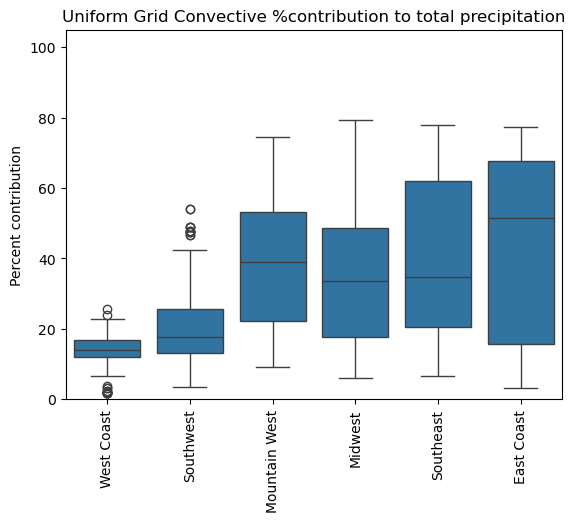

In [64]:
#plot these results
sns.boxplot(data = glob_prec, x = 'region', y = ('Value_Global','Convective_percent_glob'))
plt.tick_params(axis='x', rotation=90)
plt.ylim(0,105)
plt.title('Uniform Grid Convective %contribution to total precipitation')
plt.ylabel('Percent contribution')
plt.xlabel('')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

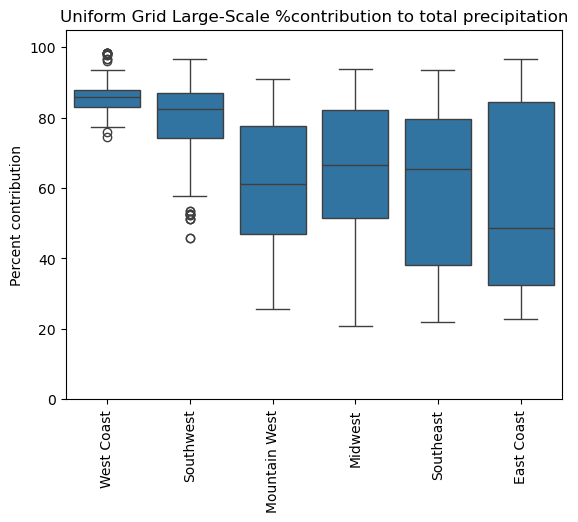

In [65]:
#plot these results
sns.boxplot(data = glob_prec, x = 'region', y = ('Value_Global','LargeScale_percent_glob'))
plt.tick_params(axis='x', rotation=90)
plt.ylim(0,105)
plt.title('Uniform Grid Large-Scale %contribution to total precipitation')
plt.ylabel('Percent contribution')
plt.xlabel('')
plt.show